# exp004 — Visual Temporal Localisation Pipeline

All detailed information goes into:

```text
config.json
split_summary.json
run_notes.md
results/*.csv
```
---

## What this notebook does

```text
1. Reuse the balanced group-disjoint split from the visual clip baseline.
2. Build frame-level visual labels from visual_fake_segments.
3. Extract frozen ConvNeXt-Base frame features.
4. Save temporal features as small shards on disk.
5. Train a simple per-frame temporal localisation head.
6. Evaluate frame-level, clip-level, localisation, and condition-level metrics.
7. Export using short internal paths so the zip can be extracted locally.
```

---

## Important difference from clip-level visual experiments

The previous visual feature-cache experiments did this:

```text
video → T frames → ConvNeXt → [T, 1024] → mean-pool → [1024] → clip classifier
```

This temporal localisation experiment does this:

```text
video → T frames → ConvNeXt → [T, 1024] → keep T features → per-frame classifier
```

# Notebook usage notes

Before running:

```text
1. Save this notebook as:
/home/jovyan/MSC_PROJECT/exp004_visual_temporal_bal40k.ipynb

2. Run cells from top to bottom.

3. The notebook snapshot cell near the end will only copy this exact file.
```

This fixes the previous snapshot issue where an outdated or different notebook was copied.

You still need to press **Ctrl+S** before the final snapshot cell, because Python can only copy the last saved version of the notebook file.

In [1]:
# Cell 1 — Core imports and reproducibility

from pathlib import Path
from datetime import datetime
import json
import shutil
import zipfile
import hashlib
import ast
import random
import time
import gc

import numpy as np
import pandas as pd

import cv2
cv2.setNumThreads(0)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.models import convnext_base, ConvNeXt_Base_Weights

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

import matplotlib.pyplot as plt
from tqdm import tqdm
from IPython.display import FileLink, display

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision("high")

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.3.1+cu121
CUDA available: True
GPU: NVIDIA A40


In [2]:
# Cell 2 — Project paths and snapshot path

PROJECT_ROOT = Path("/home/jovyan/MSC_PROJECT")
DATA_DIR = PROJECT_ROOT / "data" / "avdeepfake1mpp"
MANIFEST_DIR = DATA_DIR / "manifests"
EXPORTS_DIR = PROJECT_ROOT / "exports"
EXPORTS_DIR.mkdir(parents=True, exist_ok=True)

# IMPORTANT:
# Save this notebook at exactly this path before running the final snapshot cell.
NOTEBOOK_FILENAME = "exp004_visual_temporal_bal40k.ipynb"
NOTEBOOK_PATH = PROJECT_ROOT / NOTEBOOK_FILENAME

PATH_COL = "path"
RELATIVE_PATH_COL = "relative_path"
CONDITION_COL = "condition"
BINARY_LABEL_COL = "binary_label"

# Prefer visual_fake_segments only.
# Fallback to generic fake_segments is OFF by default because fake_segments may refer to audio or generic manipulation.
SEGMENT_COL = "visual_fake_segments"
USE_FALLBACK_FAKE_SEGMENTS = False
FALLBACK_SEGMENT_COLS = ["fake_segments"] if USE_FALLBACK_FAKE_SEGMENTS else []

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("MANIFEST_DIR:", MANIFEST_DIR)
print("EXPECTED NOTEBOOK_PATH:", NOTEBOOK_PATH)
print("Notebook exists at expected path:", NOTEBOOK_PATH.exists())

if not PROJECT_ROOT.exists():
    raise FileNotFoundError(f"PROJECT_ROOT not found: {PROJECT_ROOT}")

PROJECT_ROOT: /home/jovyan/MSC_PROJECT
DATA_DIR: /home/jovyan/MSC_PROJECT/data/avdeepfake1mpp
MANIFEST_DIR: /home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/manifests
EXPECTED NOTEBOOK_PATH: /home/jovyan/MSC_PROJECT/exp004_visual_temporal_bal40k.ipynb
Notebook exists at expected path: True


# Experiment configuration

Detailed model settings are stored in `config.json`.

In [3]:
# Cell 3 — Experiment configuration

EXPERIMENT_ID = "exp004"
EXPERIMENT_NAME = "visual_temporal_bal40k"
RUN_NAME = f"{EXPERIMENT_ID}_{EXPERIMENT_NAME}"

# Candidate split source folders.
# The notebook uses the first one that exists.
SPLIT_SOURCE_CANDIDATES = [
    "exp002_visual_clip_bal40k",
    "002_visual_convnext_base_frozen_features_linear_group_disjoint_balanced40k_16frames",
    "002_visual_convnext_base_frozen_features_linear_group_disjoint_balanced40k",
]

MODEL_NAME = "convnext_base"
NUM_FRAMES = 64
IMAGE_SIZE = 224

# Feature extraction.
# 32 worked for earlier 64-frame visual extraction, but lower to 16 if RAM becomes unstable.
FEATURE_BATCH_SIZE = 32
NUM_WORKERS = 2
PREFETCH_FACTOR = 1
PIN_MEMORY = False

# Temporal head training.
TEMPORAL_BATCH_SIZE = 32
TEMPORAL_EPOCHS = 20
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

DEFAULT_THRESHOLD = 0.5

# Missing segment policy:
# "drop"      = remove visually fake videos if segment labels are missing.
# "all_fake"  = mark all sampled frames fake for visually fake videos with missing segments.
# "keep_zero" = keep them as all-zero labels. Not recommended except debugging.
MISSING_VISUAL_SEGMENT_POLICY = "drop"

# Positive frame labels are often rare. This caps BCE pos_weight.
POS_WEIGHT_CAP = 20.0

EXPERIMENT_CONFIG = {
    "run_name": RUN_NAME,
    "task": "visual_temporal_localisation",
    "short_name": RUN_NAME,
    "model": "Frozen ConvNeXt-Base frame encoder + per-frame linear head",
    "dataset": "AV-Deepfake1M++ validation subset",
    "split_source_candidates": SPLIT_SOURCE_CANDIDATES,
    "target": "frame-level visual_fake labels from visual_fake_segments",
    "segment_col": SEGMENT_COL,
    "use_fallback_fake_segments": USE_FALLBACK_FAKE_SEGMENTS,
    "num_frames": NUM_FRAMES,
    "image_size": IMAGE_SIZE,
    "feature_batch_size": FEATURE_BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "prefetch_factor": PREFETCH_FACTOR,
    "pin_memory": PIN_MEMORY,
    "temporal_batch_size": TEMPORAL_BATCH_SIZE,
    "temporal_epochs": TEMPORAL_EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "default_threshold": DEFAULT_THRESHOLD,
    "missing_visual_segment_policy": MISSING_VISUAL_SEGMENT_POLICY,
    "pos_weight_cap": POS_WEIGHT_CAP,
    "seed": SEED,
}

EXPERIMENT_CONFIG

{'run_name': 'exp004_visual_temporal_bal40k',
 'task': 'visual_temporal_localisation',
 'short_name': 'exp004_visual_temporal_bal40k',
 'model': 'Frozen ConvNeXt-Base frame encoder + per-frame linear head',
 'dataset': 'AV-Deepfake1M++ validation subset',
 'split_source_candidates': ['exp002_visual_clip_bal40k',
  '002_visual_convnext_base_frozen_features_linear_group_disjoint_balanced40k_16frames',
  '002_visual_convnext_base_frozen_features_linear_group_disjoint_balanced40k'],
 'target': 'frame-level visual_fake labels from visual_fake_segments',
 'segment_col': 'visual_fake_segments',
 'use_fallback_fake_segments': False,
 'num_frames': 64,
 'image_size': 224,
 'feature_batch_size': 32,
 'num_workers': 2,
 'prefetch_factor': 1,
 'pin_memory': False,
 'temporal_batch_size': 32,
 'temporal_epochs': 20,
 'learning_rate': 0.001,
 'weight_decay': 0.0001,
 'default_threshold': 0.5,
 'missing_visual_segment_policy': 'drop',
 'pos_weight_cap': 20.0,
 'seed': 42}

In [4]:
# Cell 4 — Experiment folder setup

def setup_experiment_short(project_root, run_name, config):
    project_root = Path(project_root)
    run_dir = project_root / "experiments" / run_name

    dirs = {
        "run": run_dir,
        "manifests": run_dir / "manifests",
        "results": run_dir / "results",
        "checkpoints": run_dir / "checkpoints",
        "plots": run_dir / "plots",
        "notebook": run_dir / "notebook",
        "features": run_dir / "features",
    }

    for d in dirs.values():
        d.mkdir(parents=True, exist_ok=True)

    config = dict(config)
    config["created_at"] = datetime.now().isoformat(timespec="seconds")

    config_path = run_dir / "config.json"
    with open(config_path, "w") as f:
        json.dump(config, f, indent=4)

    print("Experiment folder:", run_dir)
    print("Config saved:", config_path)

    return dirs


RUN_DIRS = setup_experiment_short(PROJECT_ROOT, RUN_NAME, EXPERIMENT_CONFIG)

RUN_MANIFEST_DIR = RUN_DIRS["manifests"]
RESULTS_DIR = RUN_DIRS["results"]
CHECKPOINT_DIR = RUN_DIRS["checkpoints"]
PLOTS_DIR = RUN_DIRS["plots"]
FEATURE_DIR = RUN_DIRS["features"]

TEMPORAL_FEATURE_DIR = FEATURE_DIR / f"visual_temporal_{MODEL_NAME}_{NUM_FRAMES}f"
TEMPORAL_FEATURE_DIR.mkdir(parents=True, exist_ok=True)

print("RUN_NAME:", RUN_NAME)
print("TEMPORAL_FEATURE_DIR:", TEMPORAL_FEATURE_DIR)

Experiment folder: /home/jovyan/MSC_PROJECT/experiments/exp004_visual_temporal_bal40k
Config saved: /home/jovyan/MSC_PROJECT/experiments/exp004_visual_temporal_bal40k/config.json
RUN_NAME: exp004_visual_temporal_bal40k
TEMPORAL_FEATURE_DIR: /home/jovyan/MSC_PROJECT/experiments/exp004_visual_temporal_bal40k/features/visual_temporal_convnext_base_64f


# Split loading

This notebook does **not** create a new split.

It reuses the balanced group-disjoint split from the clip-level visual baseline. This keeps visual clip-level, visual temporal, audio, and fusion experiments comparable.

In [5]:
# Cell 5 — Locate source split and copy manifests

def find_existing_split_source(project_root, candidates):
    experiments_dir = Path(project_root) / "experiments"

    for name in candidates:
        run_dir = experiments_dir / name
        manifest_dir = run_dir / "manifests"

        train_csv = manifest_dir / "train.csv"
        val_csv = manifest_dir / "val.csv"
        test_csv = manifest_dir / "test.csv"

        if train_csv.exists() and val_csv.exists() and test_csv.exists():
            return name, run_dir, train_csv, val_csv, test_csv

    raise FileNotFoundError(
        "No split source found. Checked candidates:\n"
        + "\n".join(str(Path(project_root) / "experiments" / c) for c in candidates)
    )


SPLIT_SOURCE_EXPERIMENT, SPLIT_SOURCE_RUN_DIR, prev_train_csv, prev_val_csv, prev_test_csv = find_existing_split_source(
    PROJECT_ROOT,
    SPLIT_SOURCE_CANDIDATES,
)

print("Using split source:", SPLIT_SOURCE_EXPERIMENT)
print("Source folder:", SPLIT_SOURCE_RUN_DIR)

train_csv = RUN_MANIFEST_DIR / "train.csv"
val_csv = RUN_MANIFEST_DIR / "val.csv"
test_csv = RUN_MANIFEST_DIR / "test.csv"

shutil.copy2(prev_train_csv, train_csv)
shutil.copy2(prev_val_csv, val_csv)
shutil.copy2(prev_test_csv, test_csv)

print("Copied train:", train_csv)
print("Copied val:", val_csv)
print("Copied test:", test_csv)

Using split source: 002_visual_convnext_base_frozen_features_linear_group_disjoint_balanced40k_16frames
Source folder: /home/jovyan/MSC_PROJECT/experiments/002_visual_convnext_base_frozen_features_linear_group_disjoint_balanced40k_16frames
Copied train: /home/jovyan/MSC_PROJECT/experiments/exp004_visual_temporal_bal40k/manifests/train.csv
Copied val: /home/jovyan/MSC_PROJECT/experiments/exp004_visual_temporal_bal40k/manifests/val.csv
Copied test: /home/jovyan/MSC_PROJECT/experiments/exp004_visual_temporal_bal40k/manifests/test.csv


In [6]:
# Cell 6 — Load manifests and add modality labels

def add_modality_labels(df, condition_col=CONDITION_COL):
    df = df.copy()

    df["visual_fake"] = df[condition_col].isin([
        "fake_video_real_audio",
        "fake_video_fake_audio",
    ]).astype(int)

    df["audio_fake"] = df[condition_col].isin([
        "real_video_fake_audio",
        "fake_video_fake_audio",
    ]).astype(int)

    df["binary_label"] = ((df["visual_fake"] == 1) | (df["audio_fake"] == 1)).astype(int)

    return df


train_df = add_modality_labels(pd.read_csv(train_csv))
val_df = add_modality_labels(pd.read_csv(val_csv))
test_df = add_modality_labels(pd.read_csv(test_csv))

print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

print("\nTrain condition counts:")
print(train_df[CONDITION_COL].value_counts(dropna=False))

print("\nVal condition counts:")
print(val_df[CONDITION_COL].value_counts(dropna=False))

print("\nTest condition counts:")
print(test_df[CONDITION_COL].value_counts(dropna=False))

print("\nTrain visual_fake:")
print(train_df["visual_fake"].value_counts(dropna=False))

display(train_df.head())

Train: (28000, 26)
Val: (6000, 26)
Test: (6000, 26)

Train condition counts:
condition
real                     14000
real_video_fake_audio     4721
fake_video_real_audio     4701
fake_video_fake_audio     4578
Name: count, dtype: int64

Val condition counts:
condition
real                     3000
fake_video_fake_audio    1048
fake_video_real_audio     979
real_video_fake_audio     973
Name: count, dtype: int64

Test condition counts:
condition
real                     3000
real_video_fake_audio    1027
fake_video_fake_audio    1001
fake_video_real_audio     972
Name: count, dtype: int64

Train visual_fake:
visual_fake
0    18721
1     9279
Name: count, dtype: int64


,path,relative_path,filename,file_size_bytes,file,original,split,modify_type,audio_model,fake_segments,...,audio_decodable,audio_codec,sample_rate,channels,audio_duration,binary_label,visual_fake,audio_fake,condition,clip_group
0,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,vox_celeb_2/id08968/ozvP4aAm254/00421/fake_vid...,fake_video_real_audio.mp4,469433,vox_celeb_2/id08968/ozvP4aAm254/00421/fake_vid...,vox_celeb_2/id08968/ozvP4aAm254/00421/real.mp4,val,visual_modified,NaN,"[[2.24, 2.48]]",...,True,pcm_s16le,16000.0,1.0,6.784,1,1,0,fake_video_real_audio,vox_celeb_2/id08968/ozvP4aAm254/00421
1,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,vox_celeb_2/id04017/cAimi8EgfN8/00262/real.mp4,real.mp4,268281,vox_celeb_2/id04017/cAimi8EgfN8/00262/real.mp4,VoxCeleb2/dev/mp4/id04017/cAimi8EgfN8/00262.mp4,val,real,NaN,[],...,True,pcm_s16le,16000.0,1.0,5.120,0,0,0,real,vox_celeb_2/id04017/cAimi8EgfN8/00262
2,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,vox_celeb_2/id08993/2l7DYrXH-UE/00139/fake_vid...,fake_video_real_audio.mp4,435172,vox_celeb_2/id08993/2l7DYrXH-UE/00139/fake_vid...,vox_celeb_2/id08993/2l7DYrXH-UE/00139/real.mp4,val,visual_modified,NaN,"[[2.84, 3.1]]",...,True,pcm_s16le,16000.0,1.0,6.272,1,1,0,fake_video_real_audio,vox_celeb_2/id08993/2l7DYrXH-UE/00139
3,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,vox_celeb_2/id02306/WFLlXFx9gZg/00242/fake_vid...,fake_video_real_audio_p1.mp4,402901,vox_celeb_2/id02306/WFLlXFx9gZg/00242/fake_vid...,vox_celeb_2/id02306/WFLlXFx9gZg/00242/real.mp4,val,visual_modified,NaN,"[[2.24, 2.42]]",...,True,pcm_s16le,16000.0,1.0,5.248,1,1,0,fake_video_real_audio,vox_celeb_2/id02306/WFLlXFx9gZg/00242
4,/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/e...,vox_celeb_2/id04997/0EGqMQhivHc/00011/fake_vid...,fake_video_real_audio.mp4,491377,vox_celeb_2/id04997/0EGqMQhivHc/00011/fake_vid...,vox_celeb_2/id04997/0EGqMQhivHc/00011/real.mp4,val,visual_modified,NaN,"[[0.78, 1.1]]",...,True,pcm_s16le,16000.0,1.0,7.552,1,1,0,fake_video_real_audio,vox_celeb_2/id04997/0EGqMQhivHc/00011


In [7]:
# Cell 7 — Validate required columns

required_cols = [PATH_COL, CONDITION_COL, "visual_fake", "audio_fake", "binary_label"]

missing_required = [c for c in required_cols if c not in train_df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

if SEGMENT_COL not in train_df.columns:
    print(f"WARNING: {SEGMENT_COL} not found.")
    if USE_FALLBACK_FAKE_SEGMENTS:
        print("Fallback fake_segments is enabled.")
    else:
        print("Fallback fake_segments is disabled. Visual fake rows may be dropped if no segment labels exist.")

print("Columns available:")
print(train_df.columns.tolist())

Columns available:
['path', 'relative_path', 'filename', 'file_size_bytes', 'file', 'original', 'split', 'modify_type', 'audio_model', 'fake_segments', 'audio_fake_segments', 'visual_fake_segments', 'video_frames', 'audio_frames', 'video_model', 'has_audio_stream', 'audio_decodable', 'audio_codec', 'sample_rate', 'channels', 'audio_duration', 'binary_label', 'visual_fake', 'audio_fake', 'condition', 'clip_group']


# Segment parsing and frame-label construction

This section is deliberately cautious.

For temporal localisation, it is better to drop uncertain visually-fake rows than to create wrong frame labels.

Rules:

```text
real                     → all visual frame labels = 0
real_video_fake_audio     → all visual frame labels = 0
fake_video_real_audio     → labels from visual_fake_segments
fake_video_fake_audio     → labels from visual_fake_segments
```

By default, this notebook does **not** use generic `fake_segments` as a fallback because that may refer to audio or generic manipulation rather than visual manipulation.

In [8]:
# Cell 8 — Segment parser

def is_missing_value(x):
    if x is None:
        return True
    if isinstance(x, float) and np.isnan(x):
        return True
    if isinstance(x, str) and x.strip().lower() in ["", "nan", "none", "null"]:
        return True
    return False


def parse_segments(value):
    """Parse segment annotations from a manifest cell."""
    if is_missing_value(value):
        return []

    if isinstance(value, list):
        return value

    if isinstance(value, tuple):
        return list(value)

    if isinstance(value, dict):
        for key in ["segments", "fake_segments", "visual_fake_segments", "intervals"]:
            if key in value:
                return parse_segments(value[key])
        return [value]

    if isinstance(value, str):
        s = value.strip()

        if s in ["[]", "{}", "()"]:
            return []

        try:
            return parse_segments(json.loads(s))
        except Exception:
            pass

        try:
            return parse_segments(ast.literal_eval(s))
        except Exception:
            pass

        return []

    return []


def get_segment_bounds(segment):
    """Return (start, end, unit), where unit is seconds, frames, or unknown."""
    if segment is None:
        return None

    if isinstance(segment, dict):
        frame_keys = [
            ("start_frame", "end_frame"),
            ("frame_start", "frame_end"),
            ("start_idx", "end_idx"),
        ]

        time_keys = [
            ("start", "end"),
            ("start_time", "end_time"),
            ("time_start", "time_end"),
            ("begin", "finish"),
        ]

        for a, b in frame_keys:
            if a in segment and b in segment:
                return float(segment[a]), float(segment[b]), "frames"

        for a, b in time_keys:
            if a in segment and b in segment:
                return float(segment[a]), float(segment[b]), "seconds"

        return None

    if isinstance(segment, (list, tuple)) and len(segment) >= 2:
        return float(segment[0]), float(segment[1]), "unknown"

    return None


def get_row_segments(row):
    segments = []

    if SEGMENT_COL in row:
        segments = parse_segments(row.get(SEGMENT_COL))

    if len(segments) == 0:
        for col in FALLBACK_SEGMENT_COLS:
            if col in row:
                segments = parse_segments(row.get(col))
                if len(segments) > 0:
                    break

    return segments


def infer_units(bounds_list, duration_sec, total_frames):
    known = [u for _, _, u in bounds_list if u in ["seconds", "frames"]]
    if len(known) > 0:
        return known[0]

    if len(bounds_list) == 0:
        return "seconds"

    max_end = max(end for _, end, _ in bounds_list)

    if duration_sec is not None and total_frames is not None:
        if max_end > duration_sec + 5 and max_end <= total_frames + 5:
            return "frames"

    return "seconds"


def frame_labels_from_segments(segments, target_indices, target_times, duration_sec=None, total_frames=None):
    labels = np.zeros(len(target_indices), dtype=np.float32)

    bounds_list = []
    for seg in segments:
        bounds = get_segment_bounds(seg)
        if bounds is None:
            continue

        start, end, unit = bounds
        if end < start:
            start, end = end, start
        bounds_list.append((start, end, unit))

    if len(bounds_list) == 0:
        return labels

    inferred_unit = infer_units(bounds_list, duration_sec, total_frames)

    for start, end, unit in bounds_list:
        unit = unit if unit in ["seconds", "frames"] else inferred_unit

        if unit == "frames":
            inside = (target_indices >= start) & (target_indices <= end)
        else:
            inside = (target_times >= start) & (target_times <= end)

        labels[inside] = 1.0

    return labels

In [9]:
# Cell 9 — Segment availability audit

def segment_availability_summary(df, split_name):
    rows = []

    for condition, group in df.groupby(CONDITION_COL):
        parsed_counts = group.apply(lambda row: len(get_row_segments(row)), axis=1)
        visual_fake_value = int(group["visual_fake"].iloc[0]) if len(group) else None

        rows.append({
            "split": split_name,
            "condition": condition,
            "n_rows": len(group),
            "visual_fake": visual_fake_value,
            "rows_with_segments": int((parsed_counts > 0).sum()),
            "rows_without_segments": int((parsed_counts == 0).sum()),
            "mean_segments_per_row": float(parsed_counts.mean()) if len(parsed_counts) else 0.0,
        })

    return pd.DataFrame(rows)


segment_audit_df = pd.concat([
    segment_availability_summary(train_df, "train"),
    segment_availability_summary(val_df, "val"),
    segment_availability_summary(test_df, "test"),
], ignore_index=True)

segment_audit_path = RESULTS_DIR / "segment_availability_audit.csv"
segment_audit_df.to_csv(segment_audit_path, index=False)

display(segment_audit_df)
print("Saved:", segment_audit_path)

# Show a few raw segment examples from visual_fake rows.
visual_fake_examples = train_df[train_df["visual_fake"] == 1].head(5)
cols_to_show = [c for c in [CONDITION_COL, SEGMENT_COL, "fake_segments"] if c in visual_fake_examples.columns]
display(visual_fake_examples[cols_to_show])

,split,condition,n_rows,visual_fake,rows_with_segments,rows_without_segments,mean_segments_per_row
0,train,fake_video_fake_audio,4578,1,4578,0,1.358672
1,train,fake_video_real_audio,4701,1,4701,0,1.355456
2,train,real,14000,0,0,14000,0.000000
3,train,real_video_fake_audio,4721,0,167,4554,0.035374
4,val,fake_video_fake_audio,1048,1,1048,0,1.367366
5,val,fake_video_real_audio,979,1,979,0,1.341164
6,val,real,3000,0,0,3000,0.000000
7,val,real_video_fake_audio,973,0,35,938,0.035971
8,test,fake_video_fake_audio,1001,1,1001,0,1.357642
9,test,fake_video_real_audio,972,1,972,0,1.386831


Saved: /home/jovyan/MSC_PROJECT/experiments/exp004_visual_temporal_bal40k/results/segment_availability_audit.csv


,condition,visual_fake_segments,fake_segments
0,fake_video_real_audio,"[[2.24, 2.48]]","[[2.24, 2.48]]"
2,fake_video_real_audio,"[[2.84, 3.1]]","[[2.84, 3.1]]"
3,fake_video_real_audio,"[[2.24, 2.42]]","[[2.24, 2.42]]"
4,fake_video_real_audio,"[[0.78, 1.1]]","[[0.78, 1.1]]"
6,fake_video_real_audio,"[[0.78, 0.92]]","[[0.78, 0.92]]"


In [10]:
# Cell 10 — Filter missing visual segment labels

def filter_missing_visual_segments(df, split_name):
    df = df.copy().reset_index(drop=True)

    has_segments = df.apply(lambda row: len(get_row_segments(row)) > 0, axis=1)
    df["has_visual_segment_annotation"] = has_segments.astype(int)

    visual_fake_missing = (df["visual_fake"] == 1) & (~has_segments)

    print(f"{split_name}: total rows = {len(df)}")
    print(f"{split_name}: visual_fake rows = {int((df['visual_fake'] == 1).sum())}")
    print(f"{split_name}: visual_fake rows missing segments = {int(visual_fake_missing.sum())}")

    if MISSING_VISUAL_SEGMENT_POLICY == "drop":
        before = len(df)
        df = df[~visual_fake_missing].copy().reset_index(drop=True)
        print(f"{split_name}: dropped {before - len(df)} rows")

    elif MISSING_VISUAL_SEGMENT_POLICY in ["all_fake", "keep_zero"]:
        print(f"{split_name}: kept missing visual segments with policy {MISSING_VISUAL_SEGMENT_POLICY}")

    else:
        raise ValueError(f"Unknown policy: {MISSING_VISUAL_SEGMENT_POLICY}")

    return df


train_df = filter_missing_visual_segments(train_df, "train")
val_df = filter_missing_visual_segments(val_df, "val")
test_df = filter_missing_visual_segments(test_df, "test")

# Save filtered manifests.
train_df.to_csv(train_csv, index=False)
val_df.to_csv(val_csv, index=False)
test_df.to_csv(test_csv, index=False)

print("\nFinal split sizes after visual segment filtering:")
print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

print("\nTrain visual_fake:")
print(train_df["visual_fake"].value_counts(dropna=False))

print("\nVal visual_fake:")
print(val_df["visual_fake"].value_counts(dropna=False))

print("\nTest visual_fake:")
print(test_df["visual_fake"].value_counts(dropna=False))

train: total rows = 28000
train: visual_fake rows = 9279
train: visual_fake rows missing segments = 0
train: dropped 0 rows
val: total rows = 6000
val: visual_fake rows = 2027
val: visual_fake rows missing segments = 0
val: dropped 0 rows
test: total rows = 6000
test: visual_fake rows = 1973
test: visual_fake rows missing segments = 0
test: dropped 0 rows

Final split sizes after visual segment filtering:
Train: (28000, 27)
Val: (6000, 27)
Test: (6000, 27)

Train visual_fake:
visual_fake
0    18721
1     9279
Name: count, dtype: int64

Val visual_fake:
visual_fake
0    3973
1    2027
Name: count, dtype: int64

Test visual_fake:
visual_fake
0    4027
1    1973
Name: count, dtype: int64


In [11]:
# Cell 11 — Save split summary

def group_overlap_summary(train_df, val_df, test_df):
    if "clip_group" not in train_df.columns:
        return {
            "train_val_group_overlap": None,
            "train_test_group_overlap": None,
            "val_test_group_overlap": None,
        }

    train_groups = set(train_df["clip_group"])
    val_groups = set(val_df["clip_group"])
    test_groups = set(test_df["clip_group"])

    return {
        "train_val_group_overlap": len(train_groups & val_groups),
        "train_test_group_overlap": len(train_groups & test_groups),
        "val_test_group_overlap": len(val_groups & test_groups),
    }


split_summary = {
    "run_name": RUN_NAME,
    "split_source_experiment": SPLIT_SOURCE_EXPERIMENT,
    "missing_visual_segment_policy": MISSING_VISUAL_SEGMENT_POLICY,
    "train_rows": len(train_df),
    "val_rows": len(val_df),
    "test_rows": len(test_df),
    "train_condition_counts": train_df[CONDITION_COL].value_counts(dropna=False).to_dict(),
    "val_condition_counts": val_df[CONDITION_COL].value_counts(dropna=False).to_dict(),
    "test_condition_counts": test_df[CONDITION_COL].value_counts(dropna=False).to_dict(),
    "train_visual_fake_counts": train_df["visual_fake"].value_counts(dropna=False).to_dict(),
    "val_visual_fake_counts": val_df["visual_fake"].value_counts(dropna=False).to_dict(),
    "test_visual_fake_counts": test_df["visual_fake"].value_counts(dropna=False).to_dict(),
    **group_overlap_summary(train_df, val_df, test_df),
}

split_summary_path = RUN_DIRS["run"] / "split_summary.json"
with open(split_summary_path, "w") as f:
    json.dump(split_summary, f, indent=4)

split_summary

{'run_name': 'exp004_visual_temporal_bal40k',
 'split_source_experiment': '002_visual_convnext_base_frozen_features_linear_group_disjoint_balanced40k_16frames',
 'missing_visual_segment_policy': 'drop',
 'train_rows': 28000,
 'val_rows': 6000,
 'test_rows': 6000,
 'train_condition_counts': {'real': 14000,
  'real_video_fake_audio': 4721,
  'fake_video_real_audio': 4701,
  'fake_video_fake_audio': 4578},
 'val_condition_counts': {'real': 3000,
  'fake_video_fake_audio': 1048,
  'fake_video_real_audio': 979,
  'real_video_fake_audio': 973},
 'test_condition_counts': {'real': 3000,
  'real_video_fake_audio': 1027,
  'fake_video_fake_audio': 1001,
  'fake_video_real_audio': 972},
 'train_visual_fake_counts': {0: 18721, 1: 9279},
 'val_visual_fake_counts': {0: 3973, 1: 2027},
 'test_visual_fake_counts': {0: 4027, 1: 1973},
 'train_val_group_overlap': 0,
 'train_test_group_overlap': 0,
 'val_test_group_overlap': 0}

# Temporal feature extraction

Each feature shard stores:

```text
features:      [B, T, 1024] float16
frame_labels:  [B, T] float16
frame_times:   [B, T] float16
video_labels:  [B]
indices:       [B]
```

Feature shards are excluded from the exported zip by default because they can be several GB and are not needed for GitHub/write-up.

In [12]:
# Cell 12 — Temporal video dataset

class TemporalVideoFeatureDataset(Dataset):
    def __init__(
        self,
        csv_path,
        path_col=PATH_COL,
        num_frames=NUM_FRAMES,
        image_size=IMAGE_SIZE,
        missing_visual_segment_policy=MISSING_VISUAL_SEGMENT_POLICY,
    ):
        self.df = pd.read_csv(csv_path).reset_index(drop=True)
        self.path_col = path_col
        self.num_frames = num_frames
        self.missing_visual_segment_policy = missing_visual_segment_policy

        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225],
            ),
        ])

    def __len__(self):
        return len(self.df)

    def _labels_for_row(self, row, target_indices, target_times, duration_sec, total_frames):
        visual_fake = int(row.get("visual_fake", 0))

        # Non-visual-fake conditions should be visually real at every sampled frame.
        if visual_fake == 0:
            return np.zeros(self.num_frames, dtype=np.float32)

        segments = get_row_segments(row)

        if len(segments) == 0:
            if self.missing_visual_segment_policy == "all_fake":
                return np.ones(self.num_frames, dtype=np.float32)
            return np.zeros(self.num_frames, dtype=np.float32)

        return frame_labels_from_segments(
            segments=segments,
            target_indices=target_indices,
            target_times=target_times,
            duration_sec=duration_sec,
            total_frames=total_frames,
        )

    def _sample_frames(self, video_path, row):
        cap = cv2.VideoCapture(str(video_path))

        if not cap.isOpened():
            raise RuntimeError(f"Could not open video: {video_path}")

        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        fps = float(cap.get(cv2.CAP_PROP_FPS))

        if total_frames <= 0:
            cap.release()
            raise RuntimeError(f"No frames found: {video_path}")

        if fps <= 0 or not np.isfinite(fps):
            fps = 25.0

        duration_sec = total_frames / fps

        target_indices = np.linspace(0, total_frames - 1, self.num_frames).astype(int)
        target_times = target_indices / fps
        target_set = set(target_indices.tolist())

        frame_labels = self._labels_for_row(
            row=row,
            target_indices=target_indices,
            target_times=target_times,
            duration_sec=duration_sec,
            total_frames=total_frames,
        )

        frames = []
        current_idx = 0

        while True:
            ret, frame = cap.read()
            if not ret:
                break

            if current_idx in target_set:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame = self.transform(frame)
                frames.append(frame)

                if len(frames) == self.num_frames:
                    break

            current_idx += 1

        cap.release()

        if len(frames) == 0:
            raise RuntimeError(f"No frames sampled: {video_path}")

        while len(frames) < self.num_frames:
            frames.append(frames[-1])

        return (
            torch.stack(frames),
            torch.tensor(frame_labels, dtype=torch.float32),
            torch.tensor(target_times, dtype=torch.float32),
        )

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        frames, frame_labels, frame_times = self._sample_frames(row[self.path_col], row)

        visual_video_label = int(row.get("visual_fake", int(frame_labels.max().item() > 0)))

        return (
            frames,
            frame_labels,
            frame_times,
            torch.tensor(visual_video_label, dtype=torch.long),
            torch.tensor(idx, dtype=torch.long),
        )

In [13]:
# Cell 13 — ConvNeXt frame feature extractor

class ConvNeXtFrameFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()

        weights = ConvNeXt_Base_Weights.IMAGENET1K_V1
        self.backbone = convnext_base(weights=weights)

        # Replace final classifier projection with identity.
        self.backbone.classifier[2] = nn.Identity()

    def forward(self, x):
        # x: [B, T, C, H, W]
        B, T, C, H, W = x.shape

        x = x.reshape(B * T, C, H, W)
        frame_features = self.backbone(x)          # [B*T, 1024]
        frame_features = frame_features.reshape(B, T, -1)

        return frame_features                      # [B, T, 1024]

In [14]:
# Cell 14 — Build extraction loaders

def make_feature_loader(csv_path, shuffle=False):
    dataset = TemporalVideoFeatureDataset(
        csv_path=csv_path,
        num_frames=NUM_FRAMES,
        image_size=IMAGE_SIZE,
    )

    loader_kwargs = {
        "dataset": dataset,
        "batch_size": FEATURE_BATCH_SIZE,
        "shuffle": shuffle,
        "num_workers": NUM_WORKERS,
        "pin_memory": PIN_MEMORY,
        "persistent_workers": False,
    }

    if NUM_WORKERS > 0:
        loader_kwargs["prefetch_factor"] = PREFETCH_FACTOR
        loader_kwargs["timeout"] = 180

    return dataset, DataLoader(**loader_kwargs)


train_feature_dataset, train_feature_loader = make_feature_loader(train_csv)
val_feature_dataset, val_feature_loader = make_feature_loader(val_csv)
test_feature_dataset, test_feature_loader = make_feature_loader(test_csv)

print("Train samples:", len(train_feature_dataset))
print("Val samples:", len(val_feature_dataset))
print("Test samples:", len(test_feature_dataset))
print("Train batches:", len(train_feature_loader))
print("Val batches:", len(val_feature_loader))
print("Test batches:", len(test_feature_loader))

Train samples: 28000
Val samples: 6000
Test samples: 6000
Train batches: 875
Val batches: 188
Test batches: 188


In [15]:
# Cell 15 — One-batch sanity check

print("Trying one temporal feature batch...")

start = time.time()
frames, frame_labels, frame_times, video_labels, indices = next(iter(train_feature_loader))
elapsed = time.time() - start

print("Frames:", frames.shape)
print("Frame labels:", frame_labels.shape)
print("Frame times:", frame_times.shape)
print("Video labels:", video_labels.shape)
print("Indices:", indices.shape)
print("Positive frame labels in batch:", float(frame_labels.sum().item()))
print(f"Elapsed: {elapsed:.2f}s")

Trying one temporal feature batch...
Frames: torch.Size([32, 64, 3, 224, 224])
Frame labels: torch.Size([32, 64])
Frame times: torch.Size([32, 64])
Video labels: torch.Size([32])
Indices: torch.Size([32])
Positive frame labels in batch: 32.0
Elapsed: 10.05s


In [16]:
# Cell 16 — Sharded feature extraction

@torch.inference_mode()
def extract_temporal_feature_shards(model, loader, split_name, output_root, device):
    model.eval()

    split_dir = Path(output_root) / split_name
    split_dir.mkdir(parents=True, exist_ok=True)

    manifest_path = split_dir / "shard_manifest.csv"

    if manifest_path.exists():
        existing = pd.read_csv(manifest_path)
        if len(existing) > 0 and existing["path"].apply(lambda p: Path(p).exists()).all():
            print(f"{split_name}: complete shard manifest already exists, skipping extraction.")
            display(existing.tail())
            return existing

    rows = []
    start_time = time.time()

    progress = tqdm(loader, desc=f"extract {split_name}", leave=True, mininterval=5)

    for batch_idx, (frames, frame_labels, frame_times, video_labels, indices) in enumerate(progress):
        frames = frames.to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=(device == "cuda")):
            features = model(frames)

        features_cpu = features.detach().cpu().to(torch.float16)
        frame_labels_cpu = frame_labels.cpu().to(torch.float16)
        frame_times_cpu = frame_times.cpu().to(torch.float16)
        video_labels_cpu = video_labels.cpu()
        indices_cpu = indices.cpu()

        shard_path = split_dir / f"shard_{batch_idx:05d}.pt"

        payload = {
            "features": features_cpu,
            "frame_labels": frame_labels_cpu,
            "frame_times": frame_times_cpu,
            "video_labels": video_labels_cpu,
            "indices": indices_cpu,
            "split": split_name,
            "model_name": MODEL_NAME,
            "num_frames": NUM_FRAMES,
            "image_size": IMAGE_SIZE,
            "feature_dim": int(features_cpu.shape[-1]),
            "created_at": datetime.now().isoformat(timespec="seconds"),
        }

        torch.save(payload, shard_path)

        rows.append({
            "split": split_name,
            "shard_idx": batch_idx,
            "path": str(shard_path),
            "n_videos": int(features_cpu.shape[0]),
            "num_frames": int(features_cpu.shape[1]),
            "feature_dim": int(features_cpu.shape[2]),
            "positive_frames": float(frame_labels_cpu.sum().item()),
            "total_frames": int(frame_labels_cpu.numel()),
            "size_mb": shard_path.stat().st_size / 1024**2,
        })

        if batch_idx % 10 == 0:
            done = sum(r["n_videos"] for r in rows)
            progress.set_postfix({
                "videos": done,
                "pos": int(sum(r["positive_frames"] for r in rows)),
                "gpu": f"{torch.cuda.memory_reserved() / 1024**3:.1f}G" if device == "cuda" else "cpu",
            })
            print(f"{split_name} | shard {batch_idx}/{len(loader)} | videos={done}", flush=True)

        del frames, features, features_cpu, frame_labels_cpu, frame_times_cpu, video_labels_cpu, indices_cpu, payload
        gc.collect()
        if device == "cuda":
            torch.cuda.empty_cache()

    manifest_df = pd.DataFrame(rows)
    elapsed = time.time() - start_time
    manifest_df["elapsed_total_sec"] = elapsed

    manifest_df.to_csv(manifest_path, index=False)

    print(f"{split_name}: saved {manifest_df['n_videos'].sum()} videos across {len(manifest_df)} shards")
    print(f"{split_name}: elapsed {elapsed / 60:.2f} min")
    print("Manifest:", manifest_path)

    return manifest_df

In [17]:
# Cell 17 — Run temporal feature extraction

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

frame_encoder = ConvNeXtFrameFeatureExtractor().to(device)
frame_encoder.eval()

train_shard_manifest = extract_temporal_feature_shards(
    frame_encoder,
    train_feature_loader,
    "train",
    TEMPORAL_FEATURE_DIR,
    device,
)

val_shard_manifest = extract_temporal_feature_shards(
    frame_encoder,
    val_feature_loader,
    "val",
    TEMPORAL_FEATURE_DIR,
    device,
)

test_shard_manifest = extract_temporal_feature_shards(
    frame_encoder,
    test_feature_loader,
    "test",
    TEMPORAL_FEATURE_DIR,
    device,
)

display(train_shard_manifest.head())
display(val_shard_manifest.head())
display(test_shard_manifest.head())

Device: cuda


extract train:   0%|          | 0/875 [00:32<?, ?it/s, videos=32, pos=32, gpu=5.3G]

train | shard 0/875 | videos=32


extract train:   1%|          | 9/875 [01:24<1:32:01,  6.38s/it, videos=352, pos=359, gpu=28.1G]

train | shard 10/875 | videos=352


...

extract test: 100%|██████████| 188/188 [18:31<00:00,  5.91s/it, videos=5792, pos=6394, gpu=28.1G]


test: saved 6000 videos across 188 shards
test: elapsed 18.53 min
Manifest: /home/jovyan/MSC_PROJECT/experiments/exp004_visual_temporal_bal40k/features/visual_temporal_convnext_base_64f/test/shard_manifest.csv


,split,shard_idx,path,n_videos,num_frames,feature_dim,positive_frames,total_frames,size_mb,elapsed_total_sec
0,train,0,/home/jovyan/MSC_PROJECT/experiments/exp004_vi...,32,64,1024,32.0,2048,4.010666,4927.997814
1,train,1,/home/jovyan/MSC_PROJECT/experiments/exp004_vi...,32,64,1024,20.0,2048,4.010666,4927.997814
2,train,2,/home/jovyan/MSC_PROJECT/experiments/exp004_vi...,32,64,1024,32.0,2048,4.010666,4927.997814
3,train,3,/home/jovyan/MSC_PROJECT/experiments/exp004_vi...,32,64,1024,51.0,2048,4.010666,4927.997814
4,train,4,/home/jovyan/MSC_PROJECT/experiments/exp004_vi...,32,64,1024,29.0,2048,4.010666,4927.997814


,split,shard_idx,path,n_videos,num_frames,feature_dim,positive_frames,total_frames,size_mb,elapsed_total_sec
0,val,0,/home/jovyan/MSC_PROJECT/experiments/exp004_vi...,32,64,1024,27.0,2048,4.010666,1092.006507
1,val,1,/home/jovyan/MSC_PROJECT/experiments/exp004_vi...,32,64,1024,35.0,2048,4.010666,1092.006507
2,val,2,/home/jovyan/MSC_PROJECT/experiments/exp004_vi...,32,64,1024,45.0,2048,4.010666,1092.006507
3,val,3,/home/jovyan/MSC_PROJECT/experiments/exp004_vi...,32,64,1024,29.0,2048,4.010666,1092.006507
4,val,4,/home/jovyan/MSC_PROJECT/experiments/exp004_vi...,32,64,1024,35.0,2048,4.010666,1092.006507


,split,shard_idx,path,n_videos,num_frames,feature_dim,positive_frames,total_frames,size_mb,elapsed_total_sec
0,test,0,/home/jovyan/MSC_PROJECT/experiments/exp004_vi...,32,64,1024,33.0,2048,4.010666,1111.618015
1,test,1,/home/jovyan/MSC_PROJECT/experiments/exp004_vi...,32,64,1024,40.0,2048,4.010666,1111.618015
2,test,2,/home/jovyan/MSC_PROJECT/experiments/exp004_vi...,32,64,1024,29.0,2048,4.010666,1111.618015
3,test,3,/home/jovyan/MSC_PROJECT/experiments/exp004_vi...,32,64,1024,32.0,2048,4.010666,1111.618015
4,test,4,/home/jovyan/MSC_PROJECT/experiments/exp004_vi...,32,64,1024,37.0,2048,4.010666,1111.618015


# Train the temporal head

The temporal model is deliberately simple:

```text
frame feature [1024]
→ LayerNorm
→ Linear(1024 → 1)
→ fake probability for each sampled frame
```

This is a per-frame linear temporal baseline. It does not model temporal continuity, but it is fast and interpretable.

In [18]:
# Cell 18 — Feature shard loading helpers

def load_shard(path):
    return torch.load(path, map_location="cpu")


def get_shard_paths(split_name):
    manifest_path = Path(TEMPORAL_FEATURE_DIR) / split_name / "shard_manifest.csv"
    if not manifest_path.exists():
        raise FileNotFoundError(f"Missing shard manifest: {manifest_path}")

    manifest = pd.read_csv(manifest_path)
    paths = [Path(p) for p in manifest["path"].tolist()]

    missing = [p for p in paths if not p.exists()]
    if missing:
        raise FileNotFoundError(f"Missing shard files. First few: {missing[:5]}")

    return paths


train_shard_paths = get_shard_paths("train")
val_shard_paths = get_shard_paths("val")
test_shard_paths = get_shard_paths("test")

print("Train shards:", len(train_shard_paths))
print("Val shards:", len(val_shard_paths))
print("Test shards:", len(test_shard_paths))


def compute_frame_label_counts(shard_paths):
    positive = 0.0
    total = 0.0

    for path in tqdm(shard_paths, desc="count frame labels", leave=False):
        payload = load_shard(path)
        labels = payload["frame_labels"].float()
        positive += float(labels.sum().item())
        total += float(labels.numel())
        del payload, labels

    negative = total - positive

    return {
        "positive_frames": positive,
        "negative_frames": negative,
        "total_frames": total,
        "positive_rate": positive / total if total > 0 else 0.0,
        "negative_rate": negative / total if total > 0 else 0.0,
    }


frame_count_summary = compute_frame_label_counts(train_shard_paths)
frame_count_summary

Train shards: 875
Val shards: 188
Test shards: 188


{'positive_frames': 30842.0,
 'negative_frames': 1761158.0,
 'total_frames': 1792000.0,
 'positive_rate': 0.0172109375,
 'negative_rate': 0.9827890625}

In [19]:
# Cell 19 — Positive class weighting

positive = frame_count_summary["positive_frames"]
negative = frame_count_summary["negative_frames"]

if positive <= 0:
    raise ValueError(
        "No positive frame labels found. This usually means visual_fake_segments were not parsed correctly "
        "or all visually fake rows were dropped. Check segment_availability_audit.csv and raw segment examples."
    )

raw_pos_weight = negative / positive
pos_weight_value = min(raw_pos_weight, POS_WEIGHT_CAP)

frame_count_summary["raw_pos_weight"] = raw_pos_weight
frame_count_summary["used_pos_weight"] = pos_weight_value

label_count_path = RESULTS_DIR / "frame_label_count_summary.json"
with open(label_count_path, "w") as f:
    json.dump(frame_count_summary, f, indent=4)

print("Positive frames:", positive)
print("Negative frames:", negative)
print("Positive frame rate:", frame_count_summary["positive_rate"])
print("Raw pos_weight:", raw_pos_weight)
print("Used pos_weight:", pos_weight_value)
print("Saved:", label_count_path)

Positive frames: 30842.0
Negative frames: 1761158.0
Positive frame rate: 0.0172109375
Raw pos_weight: 57.102587380844305
Used pos_weight: 20.0
Saved: /home/jovyan/MSC_PROJECT/experiments/exp004_visual_temporal_bal40k/results/frame_label_count_summary.json


In [20]:
# Cell 20 — Temporal linear model

class TemporalLinearHead(nn.Module):
    def __init__(self, input_dim=1024, dropout=0.0):
        super().__init__()

        self.net = nn.Sequential(
            nn.LayerNorm(input_dim),
            nn.Dropout(dropout),
            nn.Linear(input_dim, 1),
        )

    def forward(self, x):
        # x: [B, T, D]
        return self.net(x).squeeze(-1)  # [B, T]

In [21]:
# Cell 21 — Shard minibatch iterator

def iter_temporal_minibatches(shard_paths, batch_size, shuffle_files=False, shuffle_within_shard=False):
    paths = list(shard_paths)

    if shuffle_files:
        random.shuffle(paths)

    for path in paths:
        payload = load_shard(path)

        X = payload["features"].float()       # [N, T, D]
        y = payload["frame_labels"].float()   # [N, T]
        indices = payload["indices"].long()   # [N]
        video_labels = payload["video_labels"].long()

        n = X.shape[0]
        order = torch.arange(n)

        if shuffle_within_shard:
            order = order[torch.randperm(n)]

        for start in range(0, n, batch_size):
            idx = order[start:start + batch_size]
            yield X[idx], y[idx], indices[idx], video_labels[idx]

        del payload, X, y, indices, video_labels


def count_videos_in_shards(shard_paths):
    total = 0
    for path in shard_paths:
        payload = load_shard(path)
        total += int(payload["features"].shape[0])
        del payload
    return total


print("Train videos:", count_videos_in_shards(train_shard_paths))
print("Val videos:", count_videos_in_shards(val_shard_paths))
print("Test videos:", count_videos_in_shards(test_shard_paths))

Train videos: 28000
Val videos: 6000
Test videos: 6000


In [22]:
# Cell 22 — Evaluation functions

def safe_auc(y_true, y_prob):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_prob)


@torch.no_grad()
def evaluate_temporal_model(model, shard_paths, criterion, device, batch_size=TEMPORAL_BATCH_SIZE, threshold=DEFAULT_THRESHOLD):
    model.eval()

    total_loss = 0.0
    total_frames = 0

    all_labels = []
    all_probs = []
    all_indices = []
    all_video_labels = []

    for X, y, indices, video_labels in iter_temporal_minibatches(
        shard_paths,
        batch_size=batch_size,
        shuffle_files=False,
        shuffle_within_shard=False,
    ):
        X = X.to(device)
        y = y.to(device)

        logits = model(X)
        loss = criterion(logits, y)
        probs = torch.sigmoid(logits)

        total_loss += float(loss.item()) * int(y.numel())
        total_frames += int(y.numel())

        all_labels.append(y.detach().cpu().reshape(-1))
        all_probs.append(probs.detach().cpu().reshape(-1))

        B, T = y.shape
        repeated_indices = indices.view(-1, 1).repeat(1, T).reshape(-1)
        repeated_video_labels = video_labels.view(-1, 1).repeat(1, T).reshape(-1)

        all_indices.append(repeated_indices.cpu())
        all_video_labels.append(repeated_video_labels.cpu())

        del X, y, logits, loss, probs

    y_true = torch.cat(all_labels).numpy().astype(int)
    y_prob = torch.cat(all_probs).numpy()
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        "loss": total_loss / max(1, total_frames),
        "frame_accuracy": accuracy_score(y_true, y_pred),
        "frame_balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "frame_f1": f1_score(y_true, y_pred, zero_division=0),
        "frame_precision": precision_score(y_true, y_pred, zero_division=0),
        "frame_recall": recall_score(y_true, y_pred, zero_division=0),
        "frame_auc": safe_auc(y_true, y_prob),
    }

    return metrics, y_true, y_prob, torch.cat(all_indices).numpy(), torch.cat(all_video_labels).numpy()

In [23]:
# Cell 23 — Train temporal head

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

temporal_model = TemporalLinearHead(input_dim=1024, dropout=0.0).to(device)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor(pos_weight_value, dtype=torch.float32, device=device)
)

optimizer = torch.optim.AdamW(
    temporal_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

best_val_auc = -1
history = []

for epoch in range(1, TEMPORAL_EPOCHS + 1):
    temporal_model.train()

    epoch_loss_sum = 0.0
    epoch_frame_count = 0

    epoch_labels = []
    epoch_probs = []

    progress = tqdm(
        iter_temporal_minibatches(
            train_shard_paths,
            batch_size=TEMPORAL_BATCH_SIZE,
            shuffle_files=True,
            shuffle_within_shard=True,
        ),
        desc=f"temporal train {epoch}/{TEMPORAL_EPOCHS}",
        leave=True,
        mininterval=5,
    )

    step = 0

    for X, y, indices, video_labels in progress:
        X = X.to(device)
        y = y.to(device)

        optimizer.zero_grad(set_to_none=True)

        logits = temporal_model(X)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        with torch.no_grad():
            probs = torch.sigmoid(logits)

        epoch_loss_sum += float(loss.item()) * int(y.numel())
        epoch_frame_count += int(y.numel())

        epoch_labels.append(y.detach().cpu().reshape(-1))
        epoch_probs.append(probs.detach().cpu().reshape(-1))

        if step % 50 == 0:
            running_loss = epoch_loss_sum / max(1, epoch_frame_count)
            progress.set_postfix({
                "loss": f"{running_loss:.4f}",
                "gpu": f"{torch.cuda.memory_reserved() / 1024**3:.1f}G" if device == "cuda" else "cpu",
            })
            print(f"epoch {epoch} | step {step} | loss={running_loss:.4f}", flush=True)

        step += 1

        del X, y, logits, loss, probs

    train_y_true = torch.cat(epoch_labels).numpy().astype(int)
    train_y_prob = torch.cat(epoch_probs).numpy()
    train_y_pred = (train_y_prob >= DEFAULT_THRESHOLD).astype(int)

    train_metrics = {
        "loss": epoch_loss_sum / max(1, epoch_frame_count),
        "frame_accuracy": accuracy_score(train_y_true, train_y_pred),
        "frame_balanced_accuracy": balanced_accuracy_score(train_y_true, train_y_pred),
        "frame_f1": f1_score(train_y_true, train_y_pred, zero_division=0),
        "frame_precision": precision_score(train_y_true, train_y_pred, zero_division=0),
        "frame_recall": recall_score(train_y_true, train_y_pred, zero_division=0),
        "frame_auc": safe_auc(train_y_true, train_y_prob),
    }

    val_metrics, _, _, _, _ = evaluate_temporal_model(
        temporal_model,
        val_shard_paths,
        criterion,
        device,
        batch_size=TEMPORAL_BATCH_SIZE,
        threshold=DEFAULT_THRESHOLD,
    )

    row = {
        "epoch": epoch,
        **{f"train_{k}": v for k, v in train_metrics.items()},
        **{f"val_{k}": v for k, v in val_metrics.items()},
    }

    history.append(row)
    history_df = pd.DataFrame(history)
    history_path = RESULTS_DIR / "temporal_training_history.csv"
    history_df.to_csv(history_path, index=False)

    print(row)

    if val_metrics["frame_auc"] > best_val_auc:
        best_val_auc = val_metrics["frame_auc"]
        checkpoint_path = CHECKPOINT_DIR / "best_temporal_head.pt"

        torch.save({
            "model_state_dict": temporal_model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "epoch": epoch,
            "val_metrics": val_metrics,
            "input_dim": 1024,
            "num_frames": NUM_FRAMES,
            "run_name": RUN_NAME,
            "feature_dir": str(TEMPORAL_FEATURE_DIR),
            "threshold": DEFAULT_THRESHOLD,
            "pos_weight": pos_weight_value,
        }, checkpoint_path)

        print("Saved best checkpoint:", checkpoint_path)

    gc.collect()
    if device == "cuda":
        torch.cuda.empty_cache()

Device: cuda


temporal train 1/20: 0it [00:00, ?it/s, loss=1.0601, gpu=0.4G]

epoch 1 | step 0 | loss=1.0601


temporal train 1/20: 40it [00:06,  7.81it/s, loss=0.7685, gpu=0.4G]

epoch 1 | step 50 | loss=0.7685


...

epoch 20 | step 800 | loss=0.6079


temporal train 20/20: 835it [01:41,  8.40it/s, loss=0.6066, gpu=0.4G]

epoch 20 | step 850 | loss=0.6066


temporal train 20/20: 875it [01:44,  8.37it/s, loss=0.6066, gpu=0.4G]


{'epoch': 20, 'train_loss': 0.6076591280528477, 'train_frame_accuracy': 0.91893359375, 'train_frame_balanced_accuracy': 0.6611150020651646, 'train_frame_f1': 0.14335332378037635, 'train_frame_precision': 0.08761054930480976, 'train_frame_recall': 0.3941054406329032, 'train_frame_auc': 0.7965981973685426, 'val_loss': 0.6220043781598409, 'val_frame_accuracy': 0.9156302083333333, 'val_frame_balanced_accuracy': 0.658860274478287, 'val_frame_f1': 0.14100116661363876, 'val_frame_precision': 0.08592664404588786, 'val_frame_recall': 0.3927041795894255, 'val_frame_auc': 0.7916129563339205}


,epoch,train_loss,train_frame_accuracy,train_frame_balanced_accuracy,train_frame_f1,train_frame_precision,train_frame_recall,train_frame_auc,val_loss,val_frame_accuracy,val_frame_balanced_accuracy,val_frame_f1,val_frame_precision,val_frame_recall,val_frame_auc
15,16,0.608687,0.919269,0.657877,0.141689,0.086711,0.387167,0.795956,0.624029,0.928919,0.645609,0.148654,0.094227,0.351942,0.790285
16,17,0.608655,0.919308,0.659761,0.142938,0.087457,0.390960,0.795870,0.621838,0.892938,0.678493,0.130641,0.076236,0.456210,0.795047
17,18,0.607618,0.919022,0.660523,0.143083,0.087473,0.392809,0.796654,0.626423,0.942773,0.627859,0.156657,0.105828,0.301433,0.792727
18,19,0.607195,0.919866,0.660236,0.143913,0.088168,0.391349,0.797228,0.623493,0.942398,0.632962,0.160474,0.107989,0.312214,0.796100
19,20,0.607659,0.918934,0.661115,0.143353,0.087611,0.394105,0.796598,0.622004,0.915630,0.658860,0.141001,0.085927,0.392704,0.791613


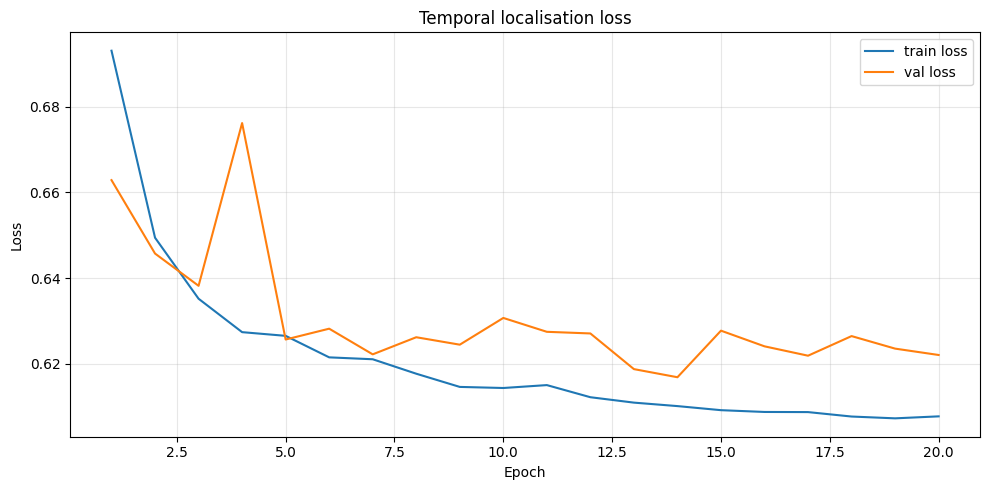

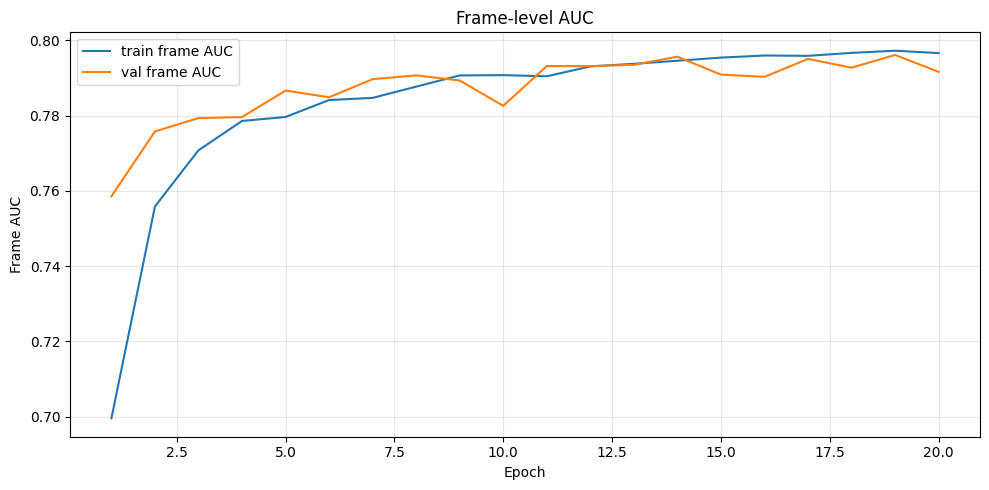

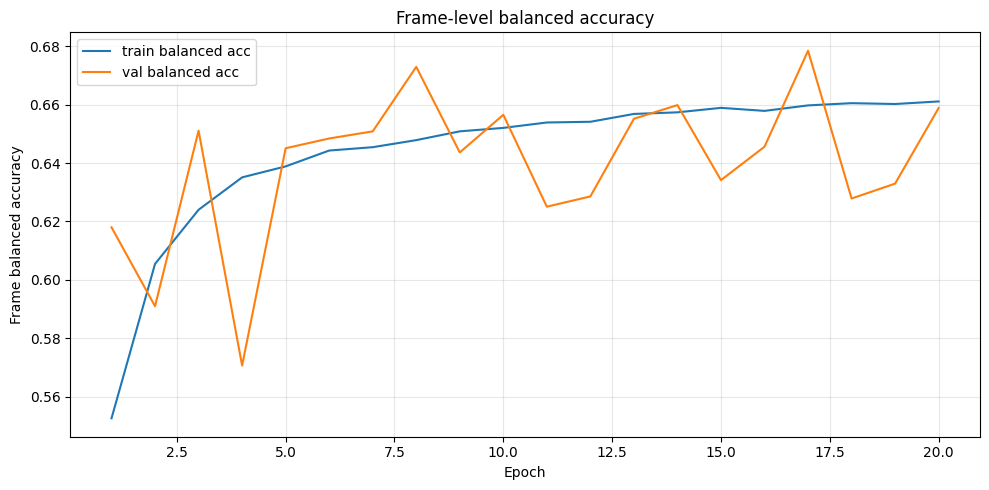

In [24]:
# Cell 24 — Plot temporal training history

history_df = pd.read_csv(RESULTS_DIR / "temporal_training_history.csv")
display(history_df.tail())

plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="train loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Temporal localisation loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "temporal_loss.png", dpi=200)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["train_frame_auc"], label="train frame AUC")
plt.plot(history_df["epoch"], history_df["val_frame_auc"], label="val frame AUC")
plt.xlabel("Epoch")
plt.ylabel("Frame AUC")
plt.title("Frame-level AUC")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "frame_auc.png", dpi=200)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["train_frame_balanced_accuracy"], label="train balanced acc")
plt.plot(history_df["epoch"], history_df["val_frame_balanced_accuracy"], label="val balanced acc")
plt.xlabel("Epoch")
plt.ylabel("Frame balanced accuracy")
plt.title("Frame-level balanced accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "frame_balanced_accuracy.png", dpi=200)
plt.show()

# Test evaluation

The test section produces:

```text
1. frame-level metrics
2. frame-level predictions CSV
3. clip-level predictions using max frame probability
4. sampled-frame IoU
5. condition-level temporal metrics
6. threshold-tuned frame metrics
```

In [25]:
# Cell 25 — Load best checkpoint and evaluate test frames

checkpoint_path = CHECKPOINT_DIR / "best_temporal_head.pt"
checkpoint = torch.load(checkpoint_path, map_location=device)

temporal_model.load_state_dict(checkpoint["model_state_dict"])

print("Loaded:", checkpoint_path)
print("Checkpoint epoch:", checkpoint["epoch"])
print("Val metrics:", checkpoint["val_metrics"])

test_frame_metrics, test_y_true, test_y_prob, test_repeated_indices, test_repeated_video_labels = evaluate_temporal_model(
    temporal_model,
    test_shard_paths,
    criterion,
    device,
    batch_size=TEMPORAL_BATCH_SIZE,
    threshold=DEFAULT_THRESHOLD,
)

test_frame_metrics_df = pd.DataFrame([{
    "threshold": DEFAULT_THRESHOLD,
    **test_frame_metrics,
}])

test_frame_metrics_path = RESULTS_DIR / "test_frame_metrics.csv"
test_frame_metrics_df.to_csv(test_frame_metrics_path, index=False)

display(test_frame_metrics_df)
print("Saved:", test_frame_metrics_path)

Loaded: /home/jovyan/MSC_PROJECT/experiments/exp004_visual_temporal_bal40k/checkpoints/best_temporal_head.pt
Checkpoint epoch: 19
Val metrics: {'loss': 0.6234931764602661, 'frame_accuracy': 0.9423984375, 'frame_balanced_accuracy': 0.6329618343603283, 'frame_f1': 0.1604736782176339, 'frame_precision': 0.10798937474458521, 'frame_recall': 0.31221385319745976, 'frame_auc': 0.7961001618030142}


,threshold,loss,frame_accuracy,frame_balanced_accuracy,frame_f1,frame_precision,frame_recall,frame_auc
0,0.5,0.608755,0.943255,0.633621,0.15992,0.107405,0.312915,0.801835


Saved: /home/jovyan/MSC_PROJECT/experiments/exp004_visual_temporal_bal40k/results/test_frame_metrics.csv


In [26]:
# Cell 26 — Frame-level prediction table

test_frame_predictions_df = pd.DataFrame({
    "row_index": test_repeated_indices,
    "frame_true": test_y_true,
    "frame_prob": test_y_prob,
})

test_frame_predictions_df["frame_pred"] = (test_frame_predictions_df["frame_prob"] >= DEFAULT_THRESHOLD).astype(int)
test_frame_predictions_df["timestep"] = test_frame_predictions_df.groupby("row_index").cumcount()

test_meta = test_df.reset_index().rename(columns={"index": "row_index"})
meta_cols = [c for c in ["row_index", CONDITION_COL, "visual_fake", "audio_fake", "binary_label"] if c in test_meta.columns]

test_frame_predictions_df = test_frame_predictions_df.merge(
    test_meta[meta_cols],
    on="row_index",
    how="left",
)

frame_pred_path = RESULTS_DIR / "test_frame_predictions.csv"
test_frame_predictions_df.to_csv(frame_pred_path, index=False)

display(test_frame_predictions_df.head())
print("Saved:", frame_pred_path)

,row_index,frame_true,frame_prob,frame_pred,timestep,condition,visual_fake,audio_fake,binary_label
0,0,0,0.068359,0,0,real,0,0,0
1,0,0,0.070340,0,1,real,0,0,0
2,0,0,0.071536,0,2,real,0,0,0
3,0,0,0.097274,0,3,real,0,0,0
4,0,0,0.081116,0,4,real,0,0,0


Saved: /home/jovyan/MSC_PROJECT/experiments/exp004_visual_temporal_bal40k/results/test_frame_predictions.csv


In [27]:
# Cell 27 — Clip-level predictions from temporal scores

clip_rows = []

for row_index, group in test_frame_predictions_df.groupby("row_index"):
    true_frames = group["frame_true"].values.astype(int)
    probs = group["frame_prob"].values

    pred_frames = (probs >= DEFAULT_THRESHOLD).astype(int)

    clip_true = int(true_frames.max() > 0)
    clip_prob_max = float(probs.max())
    clip_prob_mean = float(probs.mean())
    clip_pred = int(clip_prob_max >= DEFAULT_THRESHOLD)

    intersection = np.logical_and(true_frames == 1, pred_frames == 1).sum()
    union = np.logical_or(true_frames == 1, pred_frames == 1).sum()
    sampled_iou = float(intersection / union) if union > 0 else np.nan

    clip_rows.append({
        "row_index": int(row_index),
        "condition": group[CONDITION_COL].iloc[0],
        "visual_fake": int(group["visual_fake"].iloc[0]),
        "audio_fake": int(group["audio_fake"].iloc[0]),
        "binary_label": int(group["binary_label"].iloc[0]),
        "clip_true_visual_fake_from_frames": clip_true,
        "clip_pred_visual_fake": clip_pred,
        "clip_prob_max": clip_prob_max,
        "clip_prob_mean": clip_prob_mean,
        "positive_true_frames": int(true_frames.sum()),
        "positive_pred_frames": int(pred_frames.sum()),
        "sampled_frame_iou": sampled_iou,
    })

test_clip_predictions_df = pd.DataFrame(clip_rows)

clip_pred_path = RESULTS_DIR / "test_clip_predictions.csv"
test_clip_predictions_df.to_csv(clip_pred_path, index=False)

display(test_clip_predictions_df.head())
print("Saved:", clip_pred_path)

,row_index,condition,visual_fake,audio_fake,binary_label,clip_true_visual_fake_from_frames,clip_pred_visual_fake,clip_prob_max,clip_prob_mean,positive_true_frames,positive_pred_frames,sampled_frame_iou
0,0,real,0,0,0,0,0,0.200447,0.095493,0,0,NaN
1,1,fake_video_fake_audio,1,1,1,1,0,0.454489,0.114757,2,0,0.0
2,2,real,0,0,0,0,1,0.720882,0.222234,0,6,0.0
3,3,real,0,0,0,0,1,0.567585,0.147515,0,1,0.0
4,4,real_video_fake_audio,0,1,1,0,1,0.794543,0.342935,0,12,0.0


Saved: /home/jovyan/MSC_PROJECT/experiments/exp004_visual_temporal_bal40k/results/test_clip_predictions.csv


In [28]:
# Cell 28 — Clip-level metrics

clip_true = test_clip_predictions_df["clip_true_visual_fake_from_frames"].values.astype(int)
clip_prob = test_clip_predictions_df["clip_prob_max"].values
clip_pred = test_clip_predictions_df["clip_pred_visual_fake"].values.astype(int)

clip_metrics = {
    "threshold": DEFAULT_THRESHOLD,
    "clip_accuracy": accuracy_score(clip_true, clip_pred),
    "clip_balanced_accuracy": balanced_accuracy_score(clip_true, clip_pred),
    "clip_f1": f1_score(clip_true, clip_pred, zero_division=0),
    "clip_precision": precision_score(clip_true, clip_pred, zero_division=0),
    "clip_recall": recall_score(clip_true, clip_pred, zero_division=0),
    "clip_auc": safe_auc(clip_true, clip_prob),
}

clip_metrics_df = pd.DataFrame([clip_metrics])
clip_metrics_path = RESULTS_DIR / "test_clip_metrics.csv"
clip_metrics_df.to_csv(clip_metrics_path, index=False)

display(clip_metrics_df)
print("Saved:", clip_metrics_path)

,threshold,clip_accuracy,clip_balanced_accuracy,clip_f1,clip_precision,clip_recall,clip_auc
0,0.5,0.641333,0.616925,0.499069,0.459297,0.546381,0.67004


Saved: /home/jovyan/MSC_PROJECT/experiments/exp004_visual_temporal_bal40k/results/test_clip_metrics.csv


In [29]:
# Cell 29 — Localisation metrics on sampled-frame grid

positive_clips = test_clip_predictions_df[
    test_clip_predictions_df["clip_true_visual_fake_from_frames"] == 1
].copy()

localisation_metrics = {
    "n_positive_visual_fake_clips": len(positive_clips),
    "mean_sampled_frame_iou_positive_clips": float(positive_clips["sampled_frame_iou"].mean()) if len(positive_clips) else np.nan,
    "median_sampled_frame_iou_positive_clips": float(positive_clips["sampled_frame_iou"].median()) if len(positive_clips) else np.nan,
    "recall_iou_ge_0_1": float((positive_clips["sampled_frame_iou"] >= 0.1).mean()) if len(positive_clips) else np.nan,
    "recall_iou_ge_0_3": float((positive_clips["sampled_frame_iou"] >= 0.3).mean()) if len(positive_clips) else np.nan,
    "recall_iou_ge_0_5": float((positive_clips["sampled_frame_iou"] >= 0.5).mean()) if len(positive_clips) else np.nan,
}

localisation_metrics_df = pd.DataFrame([localisation_metrics])
localisation_metrics_path = RESULTS_DIR / "test_localisation_metrics.csv"
localisation_metrics_df.to_csv(localisation_metrics_path, index=False)

display(localisation_metrics_df)
print("Saved:", localisation_metrics_path)

,n_positive_visual_fake_clips,mean_sampled_frame_iou_positive_clips,median_sampled_frame_iou_positive_clips,recall_iou_ge_0_1,recall_iou_ge_0_3,recall_iou_ge_0_5
0,1962,0.168513,0.0,0.381753,0.230377,0.162589


Saved: /home/jovyan/MSC_PROJECT/experiments/exp004_visual_temporal_bal40k/results/test_localisation_metrics.csv


In [30]:
# Cell 30 — Condition-level metrics

condition_rows = []

for condition, frame_group in test_frame_predictions_df.groupby(CONDITION_COL):
    y_true = frame_group["frame_true"].values.astype(int)
    y_prob = frame_group["frame_prob"].values
    y_pred = frame_group["frame_pred"].values.astype(int)

    clip_group = test_clip_predictions_df[test_clip_predictions_df["condition"] == condition]

    condition_rows.append({
        "condition": condition,
        "n_videos": int(len(clip_group)),
        "n_frames": int(len(frame_group)),
        "true_positive_frame_rate": float(y_true.mean()),
        "predicted_positive_frame_rate": float(y_pred.mean()),
        "mean_frame_fake_probability": float(y_prob.mean()),
        "frame_accuracy": accuracy_score(y_true, y_pred),
        "frame_balanced_accuracy": balanced_accuracy_score(y_true, y_pred) if len(np.unique(y_true)) > 1 else np.nan,
        "frame_f1": f1_score(y_true, y_pred, zero_division=0),
        "frame_precision": precision_score(y_true, y_pred, zero_division=0),
        "frame_recall": recall_score(y_true, y_pred, zero_division=0),
        "frame_auc": safe_auc(y_true, y_prob),
        "clip_predicted_visual_fake_rate": float(clip_group["clip_pred_visual_fake"].mean()) if len(clip_group) else np.nan,
        "clip_mean_max_probability": float(clip_group["clip_prob_max"].mean()) if len(clip_group) else np.nan,
        "mean_sampled_frame_iou": float(clip_group["sampled_frame_iou"].mean()) if len(clip_group) else np.nan,
    })

condition_metrics_df = pd.DataFrame(condition_rows).sort_values("condition")

condition_metrics_path = RESULTS_DIR / "condition_temporal_metrics.csv"
condition_metrics_df.to_csv(condition_metrics_path, index=False)

display(condition_metrics_df)
print("Saved:", condition_metrics_path)

,condition,n_videos,n_frames,true_positive_frame_rate,predicted_positive_frame_rate,mean_frame_fake_probability,frame_accuracy,frame_balanced_accuracy,frame_f1,frame_precision,frame_recall,frame_auc,clip_predicted_visual_fake_rate,clip_mean_max_probability,mean_sampled_frame_iou
0,fake_video_fake_audio,1001,64064,0.049716,0.062016,0.188724,0.917895,0.624143,0.265158,0.238862,0.297959,0.782414,0.545455,0.522086,0.161233
1,fake_video_real_audio,972,62208,0.055347,0.070023,0.192764,0.910799,0.635884,0.288499,0.258264,0.326750,0.787978,0.544239,0.532225,0.175534
2,real,3000,192000,0.000000,0.041115,0.159188,0.958885,NaN,0.000000,0.000000,0.000000,NaN,0.301667,0.390619,0.000000
3,real_video_fake_audio,1027,65728,0.000000,0.046966,0.172538,0.953034,NaN,0.000000,0.000000,0.000000,NaN,0.344693,0.412706,0.000000


Saved: /home/jovyan/MSC_PROJECT/experiments/exp004_visual_temporal_bal40k/results/condition_temporal_metrics.csv


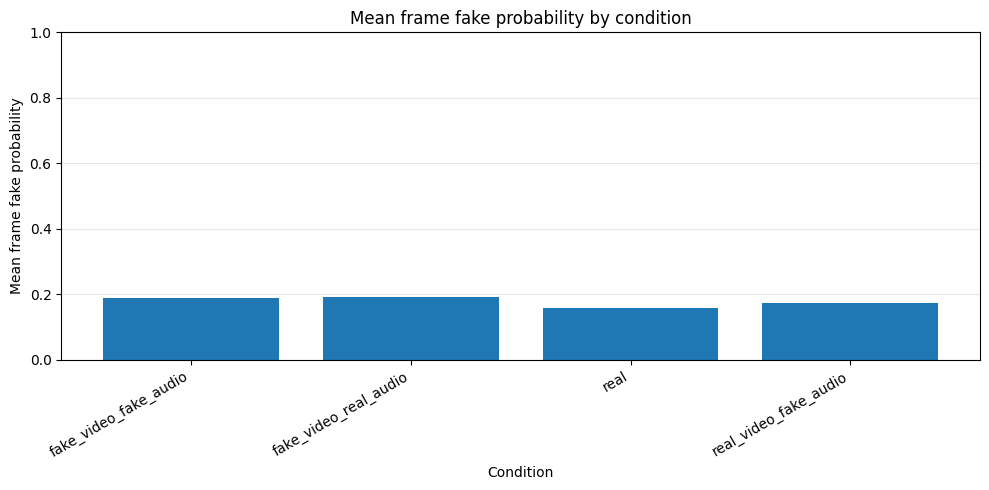

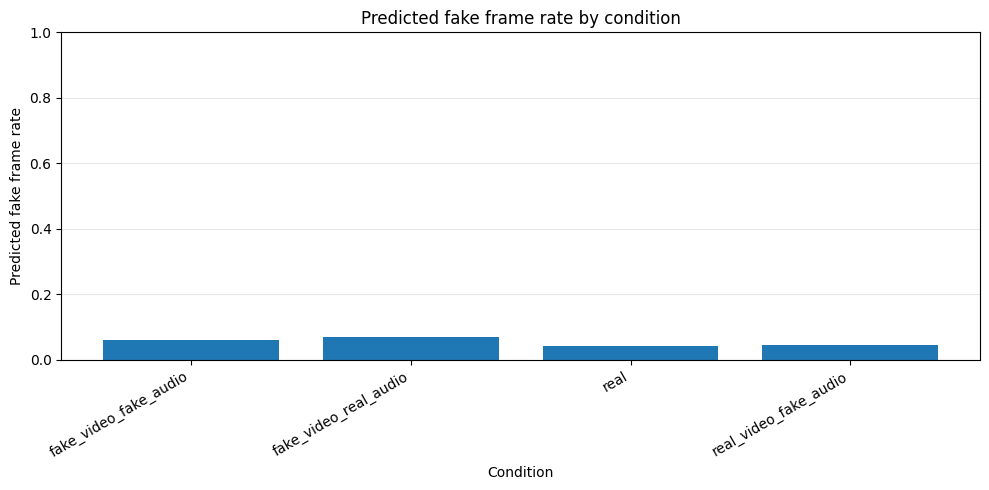

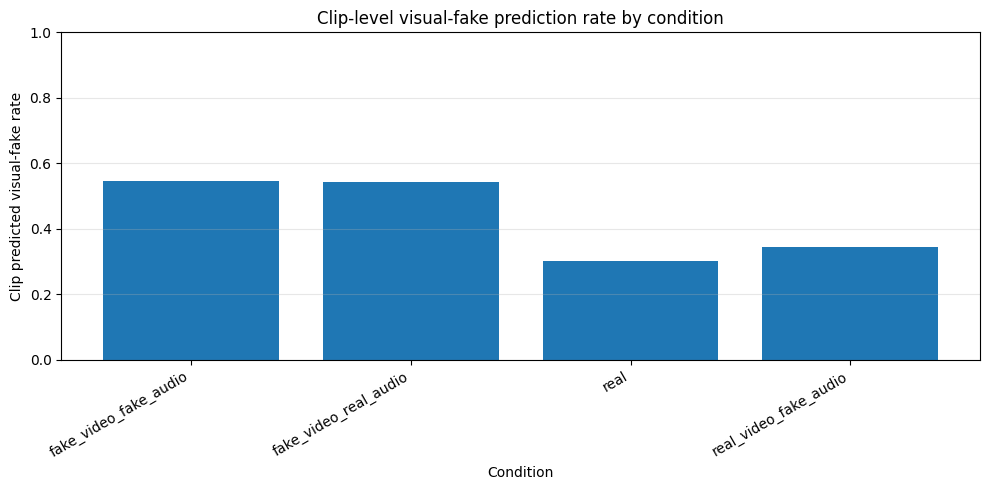

In [31]:
# Cell 31 — Condition plots

plt.figure(figsize=(10, 5))
plt.bar(condition_metrics_df["condition"], condition_metrics_df["mean_frame_fake_probability"])
plt.xlabel("Condition")
plt.ylabel("Mean frame fake probability")
plt.title("Mean frame fake probability by condition")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "condition_mean_frame_fake_probability.png", dpi=200)
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(condition_metrics_df["condition"], condition_metrics_df["predicted_positive_frame_rate"])
plt.xlabel("Condition")
plt.ylabel("Predicted fake frame rate")
plt.title("Predicted fake frame rate by condition")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "condition_predicted_positive_frame_rate.png", dpi=200)
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(condition_metrics_df["condition"], condition_metrics_df["clip_predicted_visual_fake_rate"])
plt.xlabel("Condition")
plt.ylabel("Clip predicted visual-fake rate")
plt.title("Clip-level visual-fake prediction rate by condition")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "condition_clip_visual_fake_rate.png", dpi=200)
plt.show()

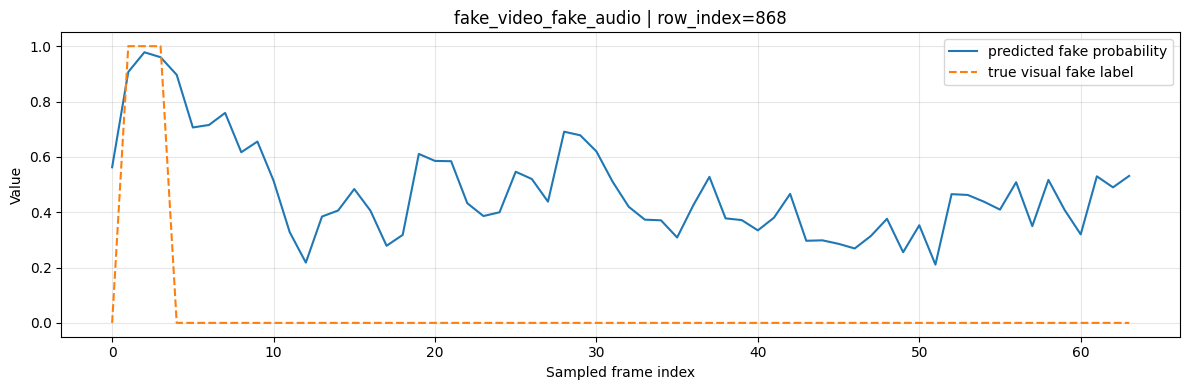

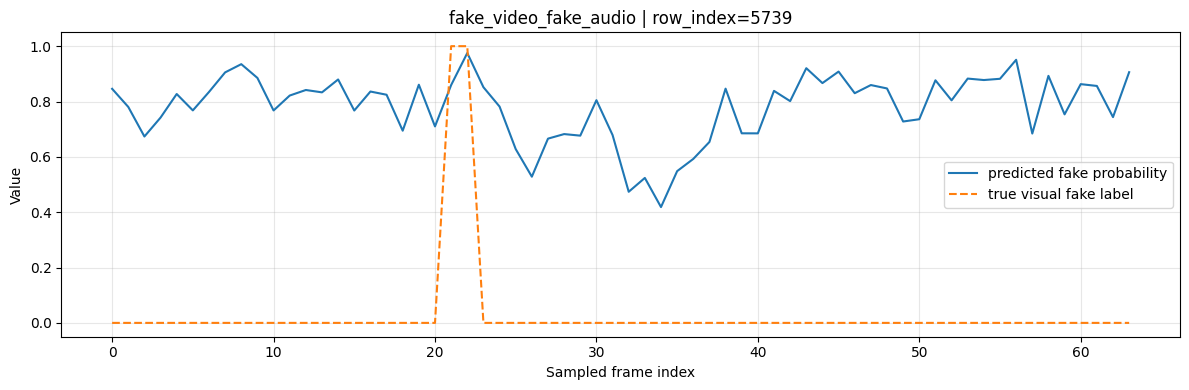

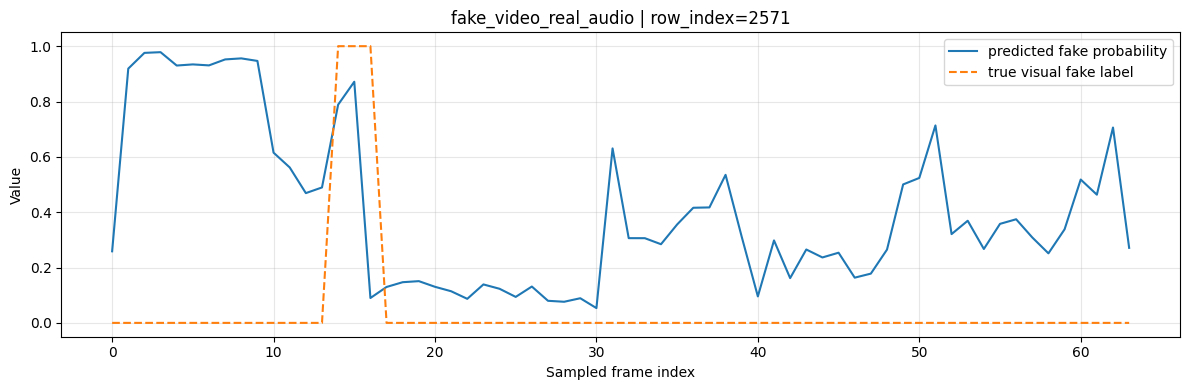

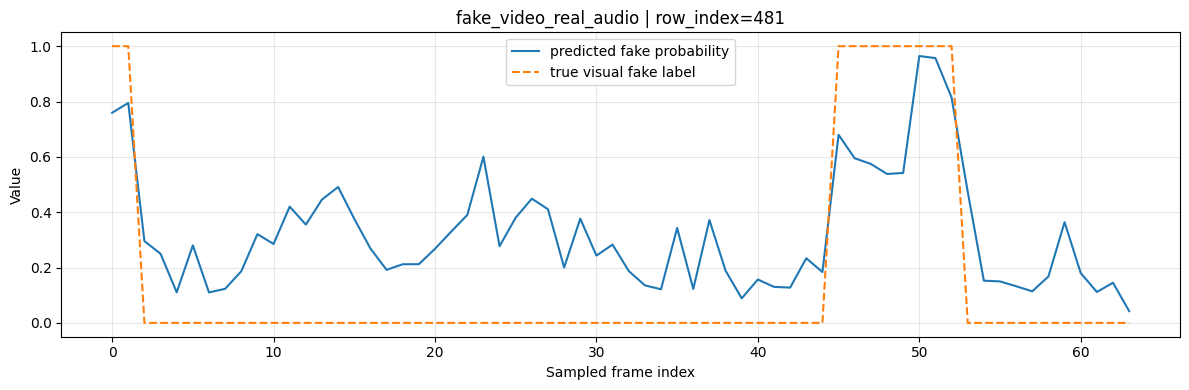

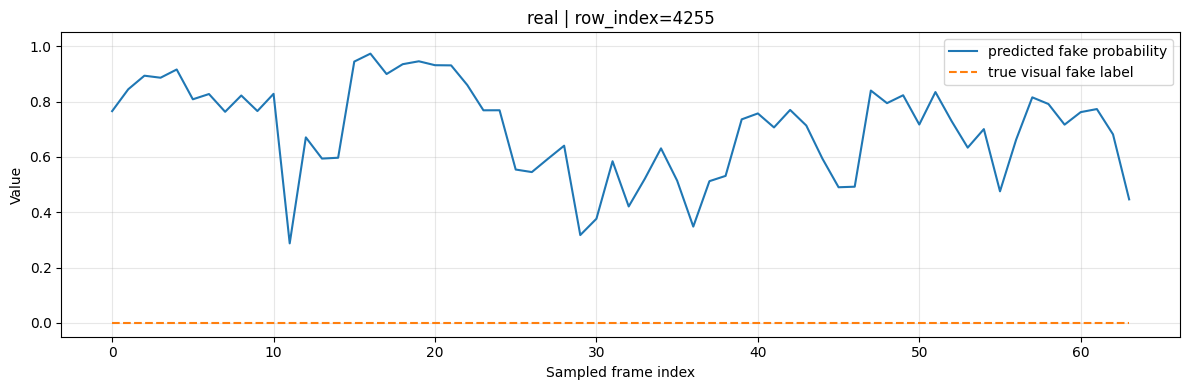

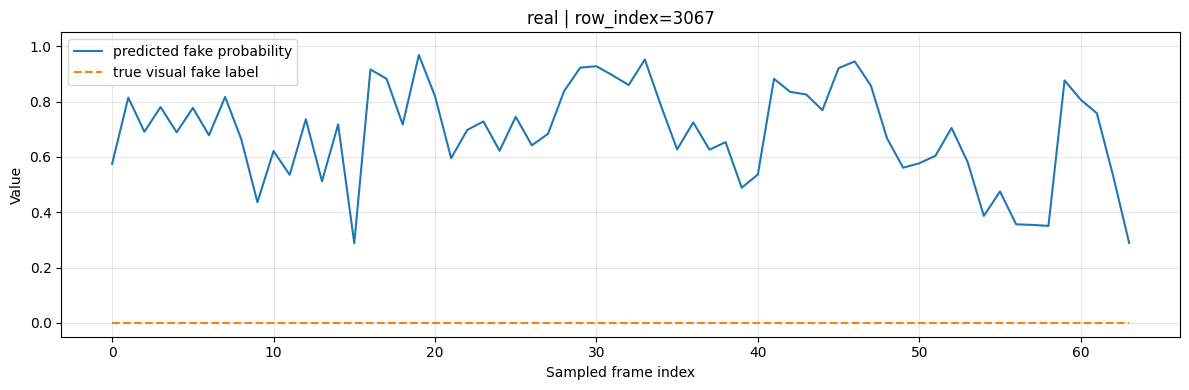

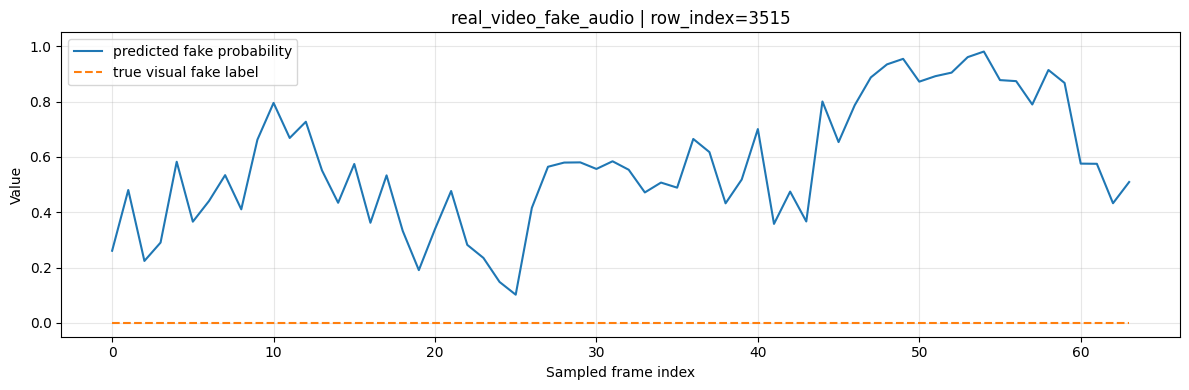

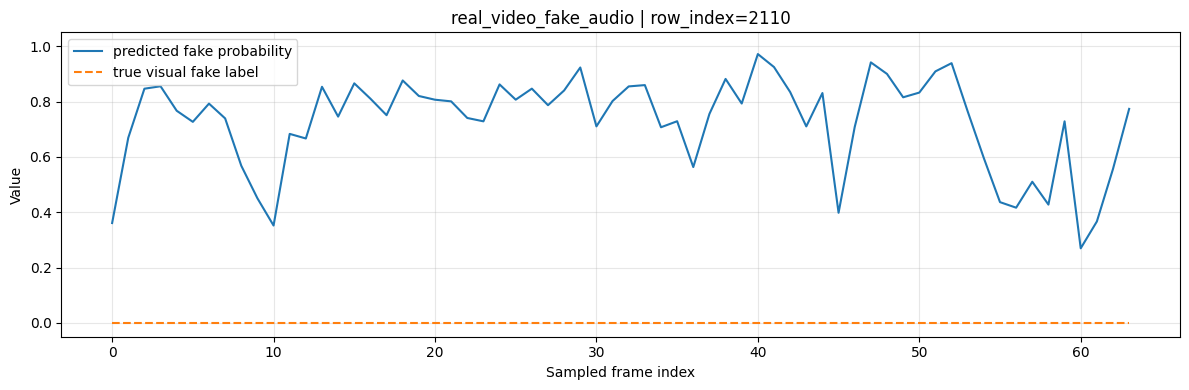

In [32]:
# Cell 32 — Example temporal plots by condition

def plot_temporal_examples(frame_df, clip_df, condition, n_examples=2):
    condition_clips = clip_df[clip_df["condition"] == condition].copy()

    if len(condition_clips) == 0:
        print("No clips for condition:", condition)
        return

    selected = (
        condition_clips.sort_values("clip_prob_max", ascending=False)
        .head(n_examples)["row_index"]
        .tolist()
    )

    for row_index in selected:
        g = frame_df[frame_df["row_index"] == row_index].sort_values("timestep")

        plt.figure(figsize=(12, 4))
        plt.plot(g["timestep"], g["frame_prob"], label="predicted fake probability")
        plt.plot(g["timestep"], g["frame_true"], label="true visual fake label", linestyle="--")
        plt.xlabel("Sampled frame index")
        plt.ylabel("Value")
        plt.title(f"{condition} | row_index={row_index}")
        plt.ylim(-0.05, 1.05)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()

        out_path = PLOTS_DIR / f"example_{condition}_row_{row_index}.png"
        plt.savefig(out_path, dpi=200)
        plt.show()


for cond in sorted(test_frame_predictions_df[CONDITION_COL].dropna().unique()):
    plot_temporal_examples(test_frame_predictions_df, test_clip_predictions_df, cond, n_examples=2)

# Threshold tuning

This does not retrain the model.

It tunes a frame-level threshold on validation probabilities to maximise frame balanced accuracy, then applies that threshold to the test probabilities.

Report this as an additional threshold-tuned analysis, not as a replacement for the default-threshold result.

In [33]:
# Cell 33 — Validation threshold search

val_frame_metrics_default, val_y_true, val_y_prob, val_repeated_indices, val_repeated_video_labels = evaluate_temporal_model(
    temporal_model,
    val_shard_paths,
    criterion,
    device,
    batch_size=TEMPORAL_BATCH_SIZE,
    threshold=DEFAULT_THRESHOLD,
)

threshold_rows = []

for t in np.linspace(0.05, 0.95, 181):
    pred = (val_y_prob >= t).astype(int)

    threshold_rows.append({
        "threshold": float(t),
        "frame_accuracy": accuracy_score(val_y_true, pred),
        "frame_balanced_accuracy": balanced_accuracy_score(val_y_true, pred),
        "frame_f1": f1_score(val_y_true, pred, zero_division=0),
        "frame_precision": precision_score(val_y_true, pred, zero_division=0),
        "frame_recall": recall_score(val_y_true, pred, zero_division=0),
    })

threshold_df = pd.DataFrame(threshold_rows)
best_threshold_row = threshold_df.sort_values("frame_balanced_accuracy", ascending=False).iloc[0]
best_threshold = float(best_threshold_row["threshold"])

threshold_path = RESULTS_DIR / "validation_threshold_search.csv"
threshold_df.to_csv(threshold_path, index=False)

display(best_threshold_row)
print("Best validation threshold:", best_threshold)
print("Saved:", threshold_path)

threshold                  0.245000
frame_accuracy             0.767487
frame_balanced_accuracy    0.721825
frame_f1                   0.092807
frame_precision            0.049832
frame_recall               0.674494
Name: 39, dtype: float64

Best validation threshold: 0.245
Saved: /home/jovyan/MSC_PROJECT/experiments/exp004_visual_temporal_bal40k/results/validation_threshold_search.csv


In [34]:
# Cell 34 — Apply tuned threshold to test frame probabilities

tuned_pred = (test_y_prob >= best_threshold).astype(int)

tuned_test_frame_metrics = {
    "threshold": best_threshold,
    "frame_accuracy": accuracy_score(test_y_true, tuned_pred),
    "frame_balanced_accuracy": balanced_accuracy_score(test_y_true, tuned_pred),
    "frame_f1": f1_score(test_y_true, tuned_pred, zero_division=0),
    "frame_precision": precision_score(test_y_true, tuned_pred, zero_division=0),
    "frame_recall": recall_score(test_y_true, tuned_pred, zero_division=0),
    "frame_auc": safe_auc(test_y_true, test_y_prob),
}

tuned_test_frame_metrics_df = pd.DataFrame([tuned_test_frame_metrics])
tuned_metrics_path = RESULTS_DIR / "test_frame_metrics_threshold_tuned.csv"
tuned_test_frame_metrics_df.to_csv(tuned_metrics_path, index=False)

display(tuned_test_frame_metrics_df)
print("Saved:", tuned_metrics_path)

,threshold,frame_accuracy,frame_balanced_accuracy,frame_f1,frame_precision,frame_recall,frame_auc
0,0.245,0.768039,0.729311,0.093026,0.049879,0.689197,0.801835


Saved: /home/jovyan/MSC_PROJECT/experiments/exp004_visual_temporal_bal40k/results/test_frame_metrics_threshold_tuned.csv


# Run notes and export

This final section fixes two previous issues:

```text
1. Notebook snapshots copied the wrong/outdated notebook.
2. Export zips had file paths too long to extract locally.
```

The snapshot function below only copies the explicit expected path:

```text
/home/jovyan/MSC_PROJECT/exp004_visual_temporal_bal40k.ipynb
```

The zip function writes short internal archive paths and excludes feature shards by default.

In [ ]:
# Cell 35 — Save run notes

run_notes = "# " + RUN_NAME + " run notes\n\n"
run_notes += "## Purpose\n\nVisual temporal localisation using frozen ConvNeXt-Base frame features.\n\n"
run_notes += "## Key methodological point\n\n"
run_notes += "This is not clip-level binary classification. The target is frame-level visual manipulation derived from `" + SEGMENT_COL + "`.\n\n"
run_notes += "## Important condition logic\n\n"
run_notes += "- real: all visual frame labels should be 0\n"
run_notes += "- real_video_fake_audio: all visual frame labels should be 0\n"
run_notes += "- fake_video_real_audio: visual fake frames from segment labels\n"
run_notes += "- fake_video_fake_audio: visual fake frames from segment labels\n\n"
run_notes += "## Shortcut analysis\n\n"
run_notes += "The most important shortcut check is predicted fake frame rate for `real_video_fake_audio`.\n\n"
run_notes += "## Config\n\n```json\n"
run_notes += json.dumps(EXPERIMENT_CONFIG, indent=2)
run_notes += "\n```\n\n"
run_notes += "## Split source\n\n" + SPLIT_SOURCE_EXPERIMENT + "\n\n"
run_notes += "## Snapshot warning\n\n"
run_notes += "The final notebook snapshot only copies:\n" + str(NOTEBOOK_PATH) + "\n"
run_notes += "Press Ctrl+S before running the snapshot cell.\n"

run_notes_path = RUN_DIRS["run"] / "run_notes.md"
run_notes_path.write_text(run_notes, encoding="utf-8")

print("Saved:", run_notes_path)

In [ ]:
# Cell 36 — Safe final notebook snapshot

def save_final_notebook_snapshot(notebook_path, run_dirs):
    notebook_path = Path(notebook_path)
    snapshot_dir = Path(run_dirs["notebook"])
    snapshot_dir.mkdir(parents=True, exist_ok=True)

    if not notebook_path.exists():
        raise FileNotFoundError(
            f"Notebook path does not exist: {notebook_path}\n"
            f"Save this notebook as {notebook_path} first, then rerun this cell."
        )

    if notebook_path.name != NOTEBOOK_FILENAME:
        raise ValueError(
            f"Refusing to snapshot unexpected notebook name: {notebook_path.name}\n"
            f"Expected: {NOTEBOOK_FILENAME}"
        )

    size_kb = notebook_path.stat().st_size / 1024
    if size_kb < 10:
        raise ValueError(f"Notebook file looks too small ({size_kb:.1f} KB). Refusing snapshot.")

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    snapshot_path = snapshot_dir / f"final_snapshot_{timestamp}.ipynb"

    shutil.copy2(notebook_path, snapshot_path)

    snapshot_note = snapshot_dir / "snapshot_source.txt"
    snapshot_note.write_text(
        f"Snapshot created at: {datetime.now().isoformat(timespec='seconds')}\n"
        f"Source notebook: {notebook_path}\n"
        f"Snapshot path: {snapshot_path}\n"
        f"Source size KB: {size_kb:.1f}\n",
        encoding="utf-8",
    )

    print("Final notebook snapshot saved:", snapshot_path)
    print("Snapshot source note:", snapshot_note)

    return snapshot_path


# Press Ctrl+S before running this cell.
snapshot_path = save_final_notebook_snapshot(NOTEBOOK_PATH, RUN_DIRS)

In [ ]:
# Cell 37 — Archive index

def create_experiment_index(run_dirs):
    run_dir = Path(run_dirs["run"])
    rows = []

    for section, folder in run_dirs.items():
        folder = Path(folder)
        if not folder.exists() or not folder.is_dir():
            continue

        for file in folder.rglob("*"):
            if not file.is_file():
                continue

            rows.append({
                "section": section,
                "filename": file.name,
                "path": str(file),
                "size_mb": file.stat().st_size / 1024**2,
                "modified_at": datetime.fromtimestamp(file.stat().st_mtime).isoformat(timespec="seconds"),
            })

    index_df = pd.DataFrame(rows).sort_values(["section", "path"])
    index_path = run_dir / "archive_index.csv"
    index_df.to_csv(index_path, index=False)

    print("Saved:", index_path)
    display(index_df)

    return index_df


experiment_index_df = create_experiment_index(RUN_DIRS)

In [ ]:
# Cell 38 — Short-path zip export

def safe_filename(name, max_len=60):
    p = Path(name)
    stem = p.stem
    suffix = p.suffix

    safe = "".join(c if c.isalnum() or c in "._-" else "_" for c in stem).strip("_-.")

    if not safe:
        safe = "file"

    if len(safe) > max_len:
        h = hashlib.md5(safe.encode("utf-8")).hexdigest()[:8]
        safe = safe[:max_len - 9] + "_" + h

    return safe + suffix


def zip_experiment_shortpaths(
    run_dir,
    exports_dir,
    short_name,
    include_checkpoints=True,
    include_features=False,
    max_filename_len=60,
):
    run_dir = Path(run_dir)
    exports_dir = Path(exports_dir)
    exports_dir.mkdir(parents=True, exist_ok=True)

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    zip_path = exports_dir / f"{short_name}_{timestamp}.zip"

    mapping_rows = []

    folder_replacements = {
        "checkpoints": "ckpt",
        "manifests": "man",
        "results": "res",
        "plots": "plt",
        "notebook": "nb",
        "features": "feat",
    }

    with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zipf:
        for file in run_dir.rglob("*"):
            if not file.is_file():
                continue

            rel = file.relative_to(run_dir)

            if ".ipynb_checkpoints" in rel.parts:
                continue

            if not include_checkpoints and file.suffix in [".pt", ".pth", ".ckpt"]:
                continue

            if not include_features and "features" in rel.parts:
                continue

            parts = []
            for part in rel.parts[:-1]:
                parts.append(folder_replacements.get(part, safe_filename(part, max_len=30)))

            parts.append(safe_filename(rel.parts[-1], max_len=max_filename_len))

            arcname = Path(short_name, *parts)

            zipf.write(file, arcname=str(arcname))

            mapping_rows.append({
                "original_path": str(file),
                "archive_path": str(arcname),
            })

        mapping_df = pd.DataFrame(mapping_rows)
        zipf.writestr(
            f"{short_name}/archive_path_mapping.csv",
            mapping_df.to_csv(index=False),
        )

    print("Created:", zip_path)
    print(f"Size: {zip_path.stat().st_size / 1024**2:.2f} MB")
    print("Features included:", include_features)

    return zip_path


zip_path = zip_experiment_shortpaths(
    run_dir=RUN_DIRS["run"],
    exports_dir=EXPORTS_DIR,
    short_name=RUN_NAME,
    include_checkpoints=True,
    include_features=False,
)

display(FileLink(str(zip_path)))

# What to report from this experiment

Report these as the main metrics:

```text
1. Frame-level AUC
2. Frame-level balanced accuracy
3. Clip-level AUC using max frame probability
4. Mean sampled-frame IoU on visual-fake clips
5. Predicted fake frame rate by condition
6. Predicted fake frame rate on real_video_fake_audio specifically
```

Do not overclaim. This is a lightweight frozen-feature temporal baseline, not an end-to-end temporal model.

Suggested wording:

```text
A frozen ConvNeXt-Base encoder was used to extract frame-level visual features from 64 uniformly sampled frames. A per-frame linear head was trained to predict visual fake labels derived from temporal segment annotations. This allowed evaluation of whether the visual stream could localise manipulated visual regions and whether it falsely activated on audio-only fake samples.
```